In [1]:
import pandas as pd
df = pd.read_csv("C:/Users/adith/Downloads/root_cause/priority_12_stores_data (1).csv")
df.head()

,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag,Date,...,ProductName,Category,Brand,IsGeneric,PackSize,ListPriceEUR,StandardCostEUR,LaunchDate,IsDiscontinued,DiscontinuedDate
0,S0000010,20240101,PH0015,PR0064,6,127.98,92.88,35.10,No,2024-01-01,...,GlucoSafe Insulin Pen 10 mg,Prescription,GlucoSafe,No,90 tablets,21.33,15.95,2024-12-15,No,NaN
1,S0000020,20240101,PH0028,PR0135,10,201.88,137.88,64.00,No,2024-01-01,...,NutriCore Probiotic Plus,Wellness,NutriCore,No,500 g,21.25,15.66,2017-03-10,No,NaN
2,S0000021,20240101,PH0028,PR0052,6,36.99,24.20,12.79,No,2024-01-01,...,AllerFree Paracetamol 20 mg,OTC,AllerFree,Yes,10 tablets,6.49,4.31,2018-02-06,No,NaN
3,S0000022,20240101,PH0028,PR0137,10,174.04,116.81,57.23,No,2024-01-01,...,ZenHealth Probiotic Daily,Wellness,ZenHealth,No,500 g,18.32,13.06,2017-01-03,No,NaN
4,S0000024,20240101,PH0031,PR0204,6,58.84,39.74,19.10,No,2024-01-01,...,PainLess Ibuprofen 20 mg,OTC,PainLess,Yes,100 ml,9.34,6.62,2017-10-02,No,NaN


In [2]:
import pandas as pd
from IPython.display import display, HTML

# Assuming your DataFrame is already loaded as 'df'
# Example: df = pd.read_csv("priority_12_stores_data (1).csv")

# Ensure 'Year' column exists (if DateKey is missing Year we derive it, but the dataset already has 'Year')
if 'Year' not in df.columns and 'DateKey' in df.columns:
    df['Year'] = df['DateKey'].astype(str).str[:4].astype(int)

# 1. Get the list of unique pharmacies
pharmacies = df['PharmacyName'].unique()

for pharmacy in pharmacies:
    display(HTML(f"<hr><h2>Diagnostic Report: {pharmacy}</h2>"))
    
    # Filter data for the specific pharmacy
    df_p = df[df['PharmacyName'] == pharmacy]
    
    # ==========================================
    # Step 1: The "Efficiency" Check (Yield & Margin)
    # ==========================================
    display(HTML("<h3>Step 1: Efficiency Check (Yield & Margin)</h3>"))
    
    eff_data = []
    for year in [2024, 2025]:
        df_year = df_p[df_p['Year'] == year]
        if not df_year.empty:
            tot_revenue = df_year['RevenueEUR'].sum()
            tot_units = df_year['UnitsSold'].sum()
            tot_margin = df_year['MarginEUR'].sum()
            
            yield_per_unit = tot_revenue / tot_units if tot_units > 0 else 0
            gross_margin_pct = (tot_margin / tot_revenue) * 100 if tot_revenue > 0 else 0
            
            eff_data.append({
                'Year': year,
                'Total Revenue': f"€{tot_revenue:,.2f}",
                'Total Units Sold': f"{tot_units:,}",
                'Total Margin': f"€{tot_margin:,.2f}",
                'Yield per Unit': yield_per_unit,
                'Gross Margin %': gross_margin_pct
            })
            
    df_eff = pd.DataFrame(eff_data)
    
    # Self-Analysis flagging
    if len(df_eff) == 2:
        y24_yield = df_eff.loc[0, 'Yield per Unit']
        y25_yield = df_eff.loc[1, 'Yield per Unit']
        y24_margin = df_eff.loc[0, 'Gross Margin %']
        y25_margin = df_eff.loc[1, 'Gross Margin %']
        
        if y25_yield < y24_yield:
            display(HTML("<p style='color:red;'><b>Self-Analysis Tip:</b> Yield per Unit is dropping! The store is substituting cheaper items.</p>"))
            
        if y25_margin >= y24_margin and float(df_eff.loc[1, 'Total Revenue'].replace('€','').replace(',','')) < float(df_eff.loc[0, 'Total Revenue'].replace('€','').replace(',','')):
            display(HTML("<p style='color:orange;'><b>Self-Analysis Tip:</b> Margin % is stable but revenue dropped. The store is losing overall volume but maintaining efficiency.</p>"))
        elif y25_margin < y24_margin and float(df_eff.loc[1, 'Total Revenue'].replace('€','').replace(',','')) < float(df_eff.loc[0, 'Total Revenue'].replace('€','').replace(',','')):
            display(HTML("<p style='color:red;'><b>Self-Analysis Tip:</b> Both gross margin and total revenue are dropping! The store is discounting or losing high-margin categories entirely.</p>"))

    # Format for display
    df_eff_display = df_eff.copy()
    df_eff_display['Yield per Unit'] = df_eff_display['Yield per Unit'].apply(lambda x: f"€{x:,.2f}")
    df_eff_display['Gross Margin %'] = df_eff_display['Gross Margin %'].apply(lambda x: f"{x:,.1f}%")
    display(df_eff_display.set_index('Year'))
    
    
    # ==========================================
    # Step 2: The "Mix Shift" Audit (Category Level)
    # ==========================================
    display(HTML("<h3>Step 2: Mix Shift Audit (Category Level)</h3>"))
    
    # Pivot share of revenue by category
    cat_pivot = df_p.groupby(['Year', 'Category'])['RevenueEUR'].sum().unstack(level=0).fillna(0)
    
    if 2024 in cat_pivot.columns and 2025 in cat_pivot.columns:
        cat_pivot['2024_%'] = (cat_pivot[2024] / cat_pivot[2024].sum()) * 100
        cat_pivot['2025_%'] = (cat_pivot[2025] / cat_pivot[2025].sum()) * 100
        cat_pivot['Delta_%'] = cat_pivot['2025_%'] - cat_pivot['2024_%']
        
        # Look for the Retail Trap
        rx_delta = cat_pivot.loc['Prescription', 'Delta_%'] if 'Prescription' in cat_pivot.index else 0
        pc_delta = cat_pivot.loc['Personal Care', 'Delta_%'] if 'Personal Care' in cat_pivot.index else 0
        
        if rx_delta < 0 and pc_delta > 0:
            display(HTML(f"<p style='color:red;'><b>Retail Trap Alert:</b> Prescription share is down ({rx_delta:.1f}%) and Personal Care is up ({pc_delta:.1f}%)!</p>"))
            
        display_pivot = cat_pivot[['2024_%', '2025_%', 'Delta_%']].sort_values('Delta_%', ascending=True).copy()
        for col in display_pivot.columns:
            display_pivot[col] = display_pivot[col].apply(lambda x: f"{x:+.1f}%")
        display(display_pivot)
    else:
        display(HTML("<p>Not enough data in both years to calculate Mix Shift Delta.</p>"))
        
        
    # ==========================================
    # Step 3: The "Anchor" Product Deep-Dive
    # ==========================================
    display(HTML("<h3>Step 3: Anchor Product Deep-Dive (Top 10 by Units Sold)</h3>"))
    
    df_p24 = df_p[df_p['Year'] == 2024]
    df_p25 = df_p[df_p['Year'] == 2025]
    
    top10_24 = df_p24.groupby('ProductName')['UnitsSold'].sum().sort_values(ascending=False).head(10)
    top10_25 = df_p25.groupby('ProductName')['UnitsSold'].sum().sort_values(ascending=False).head(10)
    
    list_24 = [f"{idx} ({val:,})" for idx, val in zip(top10_24.index, top10_24.values)]
    list_25 = [f"{idx} ({val:,})" for idx, val in zip(top10_25.index, top10_25.values)]
    
    # Ensure lists are exactly 10 in length for the dataframe visually
    list_24 += ['-'] * (10 - len(list_24))
    list_25 += ['-'] * (10 - len(list_25))
    
    anchors_df = pd.DataFrame({
        '2024 Anchor Products (Units Sold)': list_24,
        '2025 Anchor Products (Units Sold)': list_25
    })
    
    display(anchors_df)
    
    if set(top10_24.index) != set(top10_25.index):
        display(HTML("<p style='color:orange;'><b>Investigation:</b> Anchors have changed! Verify if new 2025 traffic drivers are lower-value items compared to 2024.</p>"))
        

    # ==========================================
    # Step 4: Generic vs. Branded Ratio
    # ==========================================
    display(HTML("<h3>Step 4: Generic vs. Branded Ratio (Margin Audit)</h3>"))
    
    gen_pivot = df_p.groupby(['Year', 'IsGeneric']).agg(
        Revenue=('RevenueEUR', 'sum'),
        Margin=('MarginEUR', 'sum')
    )
    
    # Calculate Gross Margin Percentage
    gen_pivot['Margin_%'] = (gen_pivot['Margin'] / gen_pivot['Revenue']) * 100
    
    # Formatting
    gen_pivot['Revenue'] = gen_pivot['Revenue'].apply(lambda x: f"€{x:,.2f}")
    gen_pivot['Margin'] = gen_pivot['Margin'].apply(lambda x: f"€{x:,.2f}")
    gen_pivot['Margin_%'] = gen_pivot['Margin_%'].apply(lambda x: f"{x:,.1f}%")
    
    display(gen_pivot)
    display(HTML("<br><br>"))



,Total Revenue,Total Units Sold,Total Margin,Yield per Unit,Gross Margin %
Year,,,,,
2024,"€52,071.97","2,917","€14,651.13",€17.85,28.1%
2025,"€55,292.63","2,949","€15,210.87",€18.75,27.5%


Year,2024_%,2025_%,Delta_%
Category,,,
Personal Care,+20.8%,+11.2%,-9.6%
OTC,+23.8%,+22.6%,-1.2%
Medical Devices,+8.5%,+9.3%,+0.8%
Wellness,+18.9%,+22.2%,+3.4%
Prescription,+28.1%,+34.7%,+6.6%


,2024 Anchor Products (Units Sold),2025 Anchor Products (Units Sold)
0,VitaCare Allergy Tabs 400 mg (68),Medica Allergy Tabs 500 mg (91)
1,DermaSoft Shampoo Repair (63),PainLess Paracetamol 20 mg (73)
2,Medica Nasal Spray 400 mg (60),FreshLine Mouthwash Sensitive (72)
3,ColdAway Paracetamol 10 mg (59),EuroRelief Paracetamol 40 mg (61)
4,ColdAway Paracetamol 200 mg (54),BioBalance Multivitamin Daily (55)
5,VitaCare Ibuprofen 200 mg (53),DigestEase Allergy Tabs 40 mg (53)
6,Medica Vitamin C 10 mg (53),PainLess Paracetamol 400 mg (53)
7,DermaSoft Moisturizer Classic (52),SmileBright Mouthwash Sensitive (50)
8,EuroRelief Antacid 500 mg (52),PainLess Ibuprofen 20 mg (48)
9,FreshLine Mouthwash Sensitive (49),Medica Paracetamol 20 mg (48)


Revenue      Margin Margin_%
Year IsGeneric                                 
2024 No         €44,938.91  €12,896.05    28.7%
     Yes         €7,133.06   €1,755.08    24.6%
2025 No         €44,649.74  €12,536.99    28.1%
     Yes        €10,642.89   €2,673.88    25.1%

,Total Revenue,Total Units Sold,Total Margin,Yield per Unit,Gross Margin %
Year,,,,,
2024,"€31,428.50","1,804","€9,035.53",€17.42,28.7%
2025,"€35,383.95","1,974","€9,885.09",€17.92,27.9%


...

Revenue      Margin Margin_%
Year IsGeneric                                 
2024 No         €62,562.15  €16,761.27    26.8%
     Yes         €9,779.83   €2,492.19    25.5%
2025 No         €53,111.48  €15,710.24    29.6%
     Yes         €9,761.86   €2,290.89    23.5%

,Total Revenue,Total Units Sold,Total Margin,Yield per Unit,Gross Margin %
Year,,,,,
2024,"€13,169.70",836,"€3,721.83",€15.75,28.3%
2025,"€11,254.48",813,"€3,291.79",€13.84,29.2%


Year,2024_%,2025_%,Delta_%
Category,,,
Personal Care,+17.8%,+10.0%,-7.8%
Medical Devices,+15.1%,+7.7%,-7.4%
Prescription,+25.7%,+25.1%,-0.7%
Wellness,+19.8%,+27.4%,+7.6%
OTC,+21.5%,+29.7%,+8.3%


,2024 Anchor Products (Units Sold),2025 Anchor Products (Units Sold)
0,DermaSoft Moisturizer Classic (38),VitaCare Antacid 100 mg (26)
1,PainLess Paracetamol 400 mg (32),NutriCore Multivitamin Active (25)
2,PainLess Throat Lozenges 20 mg (32),AllerFree Cough Syrup 400 mg (23)
3,EuroRelief Paracetamol 40 mg (22),EuroRelief Antacid 200 mg (23)
4,Medica Vitamin C 10 mg (20),ColdAway Antacid 100 mg (22)
5,EuroRelief Allergy Tabs 40 mg (20),SmileBright Hand Cream Classic (21)
6,AllerFree Paracetamol 20 mg (17),PainLess Antacid 20 mg (21)
7,DermRx ACE Inhibitor 400 mg (17),Medica Allergy Tabs 500 mg (20)
8,SmileBright Body Wash Classic (17),NatureFit Omega-3 Max (20)
9,BioBalance Probiotic Max (16),ColdAway Throat Lozenges 10 mg (19)


Revenue     Margin Margin_%
Year IsGeneric                                
2024 No         €11,029.62  €3,193.88    29.0%
     Yes         €2,140.08    €527.95    24.7%
2025 No          €8,962.52  €2,683.98    29.9%
     Yes         €2,291.96    €607.81    26.5%

In [3]:
import pandas as pd
from IPython.display import display, HTML

# Assuming your DataFrame is already loaded as 'df'
# Example: df = pd.read_csv("priority_12_stores_data (1).csv")

# Ensure 'Year' column exists
if 'Year' not in df.columns and 'DateKey' in df.columns:
    df['Year'] = df['DateKey'].astype(str).str[:4].astype(int)

# Get the list of unique pharmacies
pharmacies = df['PharmacyName'].unique()

for pharmacy in pharmacies:
    display(HTML(f"<br><hr style='border: 2px solid #333;'><h2>Diagnostic Report: {pharmacy}</h2>"))
    
    # Filter data for the specific pharmacy
    df_p = df[df['PharmacyName'] == pharmacy]
    
    # ==========================================
    # Step 1: The "Efficiency" Check (Yield & Margin)
    # ==========================================
    display(HTML("<h3>Step 1: Efficiency Check (Yield & Margin)</h3>"))
    
    eff_data = []
    for year in [2024, 2025]:
        df_year = df_p[df_p['Year'] == year]
        if not df_year.empty:
            tot_revenue = df_year['RevenueEUR'].sum()
            tot_units = df_year['UnitsSold'].sum()
            tot_margin = df_year['MarginEUR'].sum()
            
            yield_per_unit = tot_revenue / tot_units if tot_units > 0 else 0
            gross_margin_pct = (tot_margin / tot_revenue) * 100 if tot_revenue > 0 else 0
            
            eff_data.append({
                'Year': year,
                'Total Revenue': f"€{tot_revenue:,.2f}",
                'Total Units Sold': f"{tot_units:,}",
                'Total Margin': f"€{tot_margin:,.2f}",
                'Yield per Unit': yield_per_unit,
                'Gross Margin %': gross_margin_pct
            })
            
    df_eff = pd.DataFrame(eff_data)
    
    # Self-Analysis flagging
    if len(df_eff) == 2:
        y24_yield = df_eff.loc[0, 'Yield per Unit']
        y25_yield = df_eff.loc[1, 'Yield per Unit']
        y24_margin = df_eff.loc[0, 'Gross Margin %']
        y25_margin = df_eff.loc[1, 'Gross Margin %']
        
        if y25_yield < y24_yield:
            display(HTML("<p style='color:red;'><b>Self-Analysis Tip:</b> Yield per Unit is dropping! The store is selling 'cheaper' items even if they are busy.</p>"))
            
        if y25_margin >= y24_margin and float(df_eff.loc[1, 'Total Revenue'].replace('€','').replace(',','')) < float(df_eff.loc[0, 'Total Revenue'].replace('€','').replace(',','')):
            display(HTML("<p style='color:orange;'><b>Self-Analysis Tip:</b> Margin % is stable but revenue dropped. The store is losing overall volume but maintaining efficiency.</p>"))
        elif y25_margin < y24_margin and float(df_eff.loc[1, 'Total Revenue'].replace('€','').replace(',','')) < float(df_eff.loc[0, 'Total Revenue'].replace('€','').replace(',','')):
            display(HTML("<p style='color:red;'><b>Self-Analysis Tip:</b> Both gross margin and total revenue are dropping! The store is likely discounting or losing high-margin categories entirely.</p>"))

    # Format for display
    df_eff_display = df_eff.copy()
    if not df_eff_display.empty:
        df_eff_display['Yield per Unit'] = df_eff_display['Yield per Unit'].apply(lambda x: f"€{x:,.2f}")
        df_eff_display['Gross Margin %'] = df_eff_display['Gross Margin %'].apply(lambda x: f"{x:,.1f}%")
        display(df_eff_display.set_index('Year'))
    
    
    # ==========================================
    # Step 2: The "Mix Shift" Audit (Category Level)
    # ==========================================
    display(HTML("<h3>Step 2: Mix Shift Audit (Category Level)</h3>"))
    
    # Pivot share of revenue by category
    cat_pivot = df_p.groupby(['Year', 'Category'])['RevenueEUR'].sum().unstack(level=0).fillna(0)
    
    if 2024 in cat_pivot.columns and 2025 in cat_pivot.columns:
        cat_pivot['2024_%'] = (cat_pivot[2024] / cat_pivot[2024].sum()) * 100
        cat_pivot['2025_%'] = (cat_pivot[2025] / cat_pivot[2025].sum()) * 100
        cat_pivot['Delta_pp'] = cat_pivot['2025_%'] - cat_pivot['2024_%']
        
        # Look for the Retail Trap
        rx_delta = cat_pivot.loc['Prescription', 'Delta_pp'] if 'Prescription' in cat_pivot.index else 0
        pc_delta = cat_pivot.loc['Personal Care', 'Delta_pp'] if 'Personal Care' in cat_pivot.index else 0
        
        if rx_delta < 0 and pc_delta > 0:
            display(HTML(f"<p style='color:red;'><b>Retail Trap Alert:</b> Prescription share is down ({rx_delta:.1f}pp) and Personal Care is up ({pc_delta:.1f}pp). Substituting high-value medical sales with low-margin retail sales!</p>"))
            
        display_pivot = cat_pivot[['2024_%', '2025_%', 'Delta_pp']].sort_values('Delta_pp', ascending=True).copy()
        for col in display_pivot.columns:
            display_pivot[col] = display_pivot[col].apply(lambda x: f"{x:+.1f}%" if 'Delta' in col else f"{x:.1f}%")
        display(display_pivot)
    else:
        display(HTML("<p>Not enough data in both years to calculate Mix Shift Delta.</p>"))
        
        
    # ==========================================
    # Step 3: The "Anchor" Product Deep-Dive
    # ==========================================
    display(HTML("<h3>Step 3: Anchor Product Deep-Dive (Top 10 by Units Sold)</h3>"))
    
    df_p24 = df_p[df_p['Year'] == 2024]
    df_p25 = df_p[df_p['Year'] == 2025]
    
    top10_24 = df_p24.groupby('ProductName')['UnitsSold'].sum().sort_values(ascending=False).head(10)
    top10_25 = df_p25.groupby('ProductName')['UnitsSold'].sum().sort_values(ascending=False).head(10)
    
    list_24 = [f"{idx} ({val:,})" for idx, val in zip(top10_24.index, top10_24.values)]
    list_25 = [f"{idx} ({val:,})" for idx, val in zip(top10_25.index, top10_25.values)]
    
    # Ensure lists are exactly 10 in length for the dataframe visually
    list_24 += ['-'] * (10 - len(list_24))
    list_25 += ['-'] * (10 - len(list_25))
    
    anchors_df = pd.DataFrame({
        '2024 Anchor Products (Units Sold)': list_24,
        '2025 Anchor Products (Units Sold)': list_25
    })
    
    display(anchors_df)
    
    if set(top10_24.index) != set(top10_25.index):
        display(HTML("<p style='color:orange;'><b>Investigation:</b> Anchors have changed! Verify if new 2025 anchor products shifted from clinical/strategic to low-value retail items.</p>"))
        

    # ==========================================
    # Step 4: Generic vs. Branded Ratio
    # ==========================================
    display(HTML("<h3>Step 4: Generic vs. Branded Ratio (Margin Audit)</h3>"))
    
    gen_pivot = df_p.groupby(['Year', 'IsGeneric']).agg(
        Revenue=('RevenueEUR', 'sum'),
        Margin=('MarginEUR', 'sum')
    )
    
    # Calculate Gross Margin Percentage
    gen_pivot['Margin_%'] = (gen_pivot['Margin'] / gen_pivot['Revenue']) * 100
    
    # Check for High Brand / Low Margin
    branded_25 = df_p25[df_p25['IsGeneric'] == 'No']
    if not branded_25.empty:
        brand_margin = (branded_25['MarginEUR'].sum() / branded_25['RevenueEUR'].sum()) * 100
        if brand_margin < 20: # Example Threshold for low margin validation 
             display(HTML("<p style='color:orange;'><b>Strategy Tip:</b> Branded sales present but margin is low. Consider a 'Generic Conversion' push.</p>"))

    # Formatting 
    gen_pivot_display = gen_pivot.copy()
    gen_pivot_display['Revenue'] = gen_pivot_display['Revenue'].apply(lambda x: f"€{x:,.2f}")
    gen_pivot_display['Margin'] = gen_pivot_display['Margin'].apply(lambda x: f"€{x:,.2f}")
    gen_pivot_display['Margin_%'] = gen_pivot_display['Margin_%'].apply(lambda x: f"{x:,.1f}%")
    
    display(gen_pivot_display)
    
    
    # ==========================================
    # Step 5: The Promotional Audit
    # ==========================================
    display(HTML("<h3>Step 5: The Promotional Audit</h3>"))
    
    promo_data = []
    
    for year in [2024, 2025]:
        df_yr = df_p[df_p['Year'] == year]
        if not df_yr.empty:
            total_rev = df_yr['RevenueEUR'].sum()
            total_margin = df_yr['MarginEUR'].sum()
            
            # Filter promo and non-promo segments
            promo_df = df_yr[df_yr['PromoFlag'] == 'Yes']
            nonpromo_df = df_yr[df_yr['PromoFlag'] == 'No']
            
            promo_rev = promo_df['RevenueEUR'].sum()
            promo_margin = promo_df['MarginEUR'].sum()
            nonpromo_rev = nonpromo_df['RevenueEUR'].sum()
            nonpromo_margin = nonpromo_df['MarginEUR'].sum()
            
            promo_share_rev = (promo_rev / total_rev) * 100 if total_rev > 0 else 0
            promo_margin_pct = (promo_margin / promo_rev) * 100 if promo_rev > 0 else 0
            nonpromo_margin_pct = (nonpromo_margin / nonpromo_rev) * 100 if nonpromo_rev > 0 else 0
            
            promo_data.append({
                'Year': year,
                'Promo Share of Revenue (%)': promo_share_rev,
                'Promo Items Gross Margin (%)': promo_margin_pct,
                'Non-Promo Items Gross Margin (%)': nonpromo_margin_pct,
                'Total Margin (€)': total_margin
            })
            
    df_promo = pd.DataFrame(promo_data)
    
    if len(df_promo) == 2:
        y24_promo_share = df_promo.loc[0, 'Promo Share of Revenue (%)']
        y25_promo_share = df_promo.loc[1, 'Promo Share of Revenue (%)']
        y24_total_margin = df_promo.loc[0, 'Total Margin (€)']
        y25_total_margin = df_promo.loc[1, 'Total Margin (€)']
        
        # Check Discount Spiral Condition 
        if (y25_promo_share > y24_promo_share) and (y25_total_margin <= (y24_total_margin * 1.05)): 
            display(HTML("<p style='color:red;'><b>Discount Spiral Alert:</b> The store is over-relying on discounts! Promo share has increased, but Total Margin stayed flat or dropped. They are working harder for less money to 'buy' customers back.</p>"))

    if not df_promo.empty:
        df_promo_display = df_promo.copy()
        df_promo_display['Total Margin (€)'] = df_promo_display['Total Margin (€)'].apply(lambda x: f"€{x:,.2f}")
        df_promo_display['Promo Share of Revenue (%)'] = df_promo_display['Promo Share of Revenue (%)'].apply(lambda x: f"{x:,.1f}%")
        df_promo_display['Promo Items Gross Margin (%)'] = df_promo_display['Promo Items Gross Margin (%)'].apply(lambda x: f"{x:,.1f}%" if pd.notnull(x) else "0.0%")
        df_promo_display['Non-Promo Items Gross Margin (%)'] = df_promo_display['Non-Promo Items Gross Margin (%)'].apply(lambda x: f"{x:,.1f}%" if pd.notnull(x) else "0.0%")

        display(df_promo_display.set_index('Year'))
    


,Total Revenue,Total Units Sold,Total Margin,Yield per Unit,Gross Margin %
Year,,,,,
2024,"€52,071.97","2,917","€14,651.13",€17.85,28.1%
2025,"€55,292.63","2,949","€15,210.87",€18.75,27.5%


Year,2024_%,2025_%,Delta_pp
Category,,,
Personal Care,20.8%,11.2%,-9.6%
OTC,23.8%,22.6%,-1.2%
Medical Devices,8.5%,9.3%,+0.8%
Wellness,18.9%,22.2%,+3.4%
Prescription,28.1%,34.7%,+6.6%


,2024 Anchor Products (Units Sold),2025 Anchor Products (Units Sold)
0,VitaCare Allergy Tabs 400 mg (68),Medica Allergy Tabs 500 mg (91)
1,DermaSoft Shampoo Repair (63),PainLess Paracetamol 20 mg (73)
2,Medica Nasal Spray 400 mg (60),FreshLine Mouthwash Sensitive (72)
3,ColdAway Paracetamol 10 mg (59),EuroRelief Paracetamol 40 mg (61)
4,ColdAway Paracetamol 200 mg (54),BioBalance Multivitamin Daily (55)
5,VitaCare Ibuprofen 200 mg (53),DigestEase Allergy Tabs 40 mg (53)
6,Medica Vitamin C 10 mg (53),PainLess Paracetamol 400 mg (53)
7,DermaSoft Moisturizer Classic (52),SmileBright Mouthwash Sensitive (50)
8,EuroRelief Antacid 500 mg (52),PainLess Ibuprofen 20 mg (48)
9,FreshLine Mouthwash Sensitive (49),Medica Paracetamol 20 mg (48)


Revenue      Margin Margin_%
Year IsGeneric                                 
2024 No         €44,938.91  €12,896.05    28.7%
     Yes         €7,133.06   €1,755.08    24.6%
2025 No         €44,649.74  €12,536.99    28.1%
     Yes        €10,642.89   €2,673.88    25.1%

,Promo Share of Revenue (%),Promo Items Gross Margin (%),Non-Promo Items Gross Margin (%),Total Margin (€)
Year,,,,
2024,14.2%,21.1%,29.3%,"€14,651.13"
2025,13.9%,17.1%,29.2%,"€15,210.87"


...

,Total Revenue,Total Units Sold,Total Margin,Yield per Unit,Gross Margin %
Year,,,,,
2024,"€13,169.70",836,"€3,721.83",€15.75,28.3%
2025,"€11,254.48",813,"€3,291.79",€13.84,29.2%


Year,2024_%,2025_%,Delta_pp
Category,,,
Personal Care,17.8%,10.0%,-7.8%
Medical Devices,15.1%,7.7%,-7.4%
Prescription,25.7%,25.1%,-0.7%
Wellness,19.8%,27.4%,+7.6%
OTC,21.5%,29.7%,+8.3%


,2024 Anchor Products (Units Sold),2025 Anchor Products (Units Sold)
0,DermaSoft Moisturizer Classic (38),VitaCare Antacid 100 mg (26)
1,PainLess Paracetamol 400 mg (32),NutriCore Multivitamin Active (25)
2,PainLess Throat Lozenges 20 mg (32),AllerFree Cough Syrup 400 mg (23)
3,EuroRelief Paracetamol 40 mg (22),EuroRelief Antacid 200 mg (23)
4,Medica Vitamin C 10 mg (20),ColdAway Antacid 100 mg (22)
5,EuroRelief Allergy Tabs 40 mg (20),SmileBright Hand Cream Classic (21)
6,AllerFree Paracetamol 20 mg (17),PainLess Antacid 20 mg (21)
7,DermRx ACE Inhibitor 400 mg (17),Medica Allergy Tabs 500 mg (20)
8,SmileBright Body Wash Classic (17),NatureFit Omega-3 Max (20)
9,BioBalance Probiotic Max (16),ColdAway Throat Lozenges 10 mg (19)


Revenue     Margin Margin_%
Year IsGeneric                                
2024 No         €11,029.62  €3,193.88    29.0%
     Yes         €2,140.08    €527.95    24.7%
2025 No          €8,962.52  €2,683.98    29.9%
     Yes         €2,291.96    €607.81    26.5%

,Promo Share of Revenue (%),Promo Items Gross Margin (%),Non-Promo Items Gross Margin (%),Total Margin (€)
Year,,,,
2024,8.6%,18.9%,29.1%,"€3,721.83"
2025,8.7%,19.8%,30.1%,"€3,291.79"


**KATOWICE HEALTHPOINT #080**

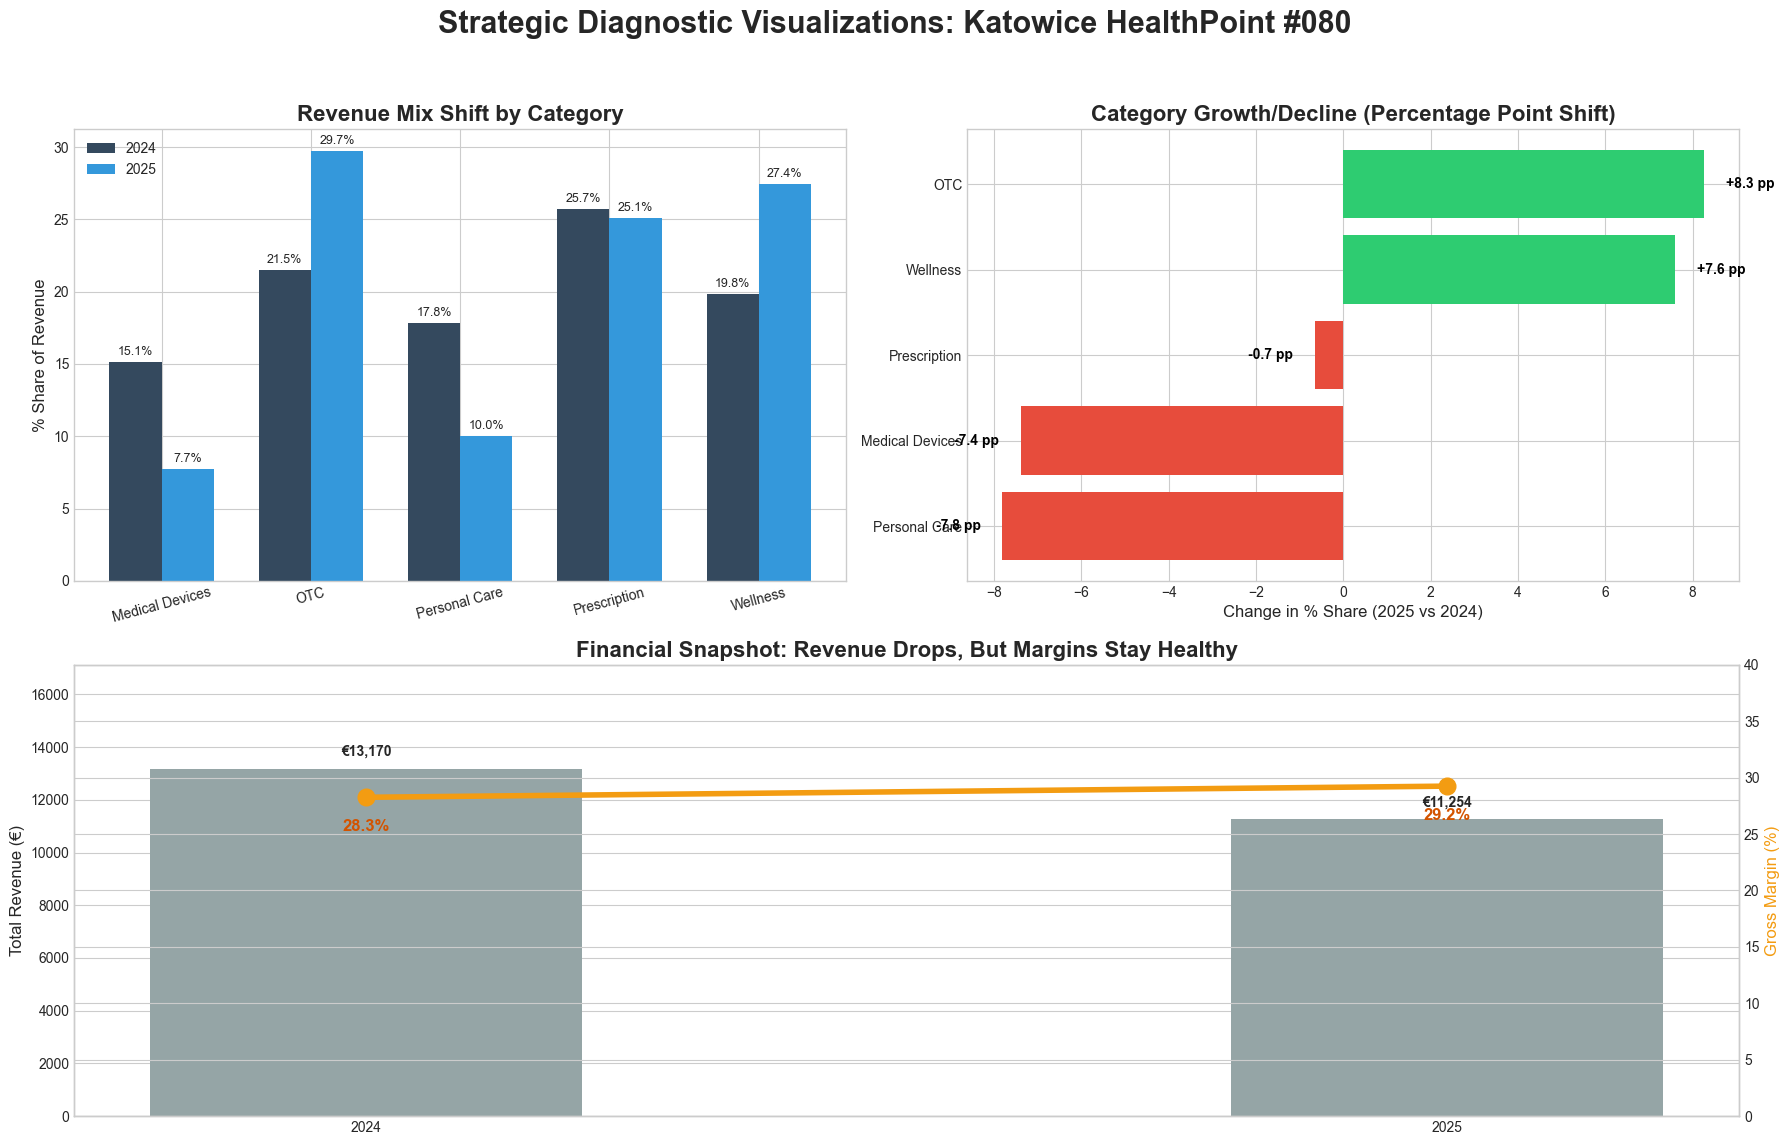

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame 'df' is loaded. If you are doing this for one specific store:
pharmacy_name = 'Katowice HealthPoint #080'
df_p = df[df['PharmacyName'] == pharmacy_name].copy()

# Ensure 'Year' column exists
if 'Year' not in df_p.columns and 'DateKey' in df_p.columns:
    df_p['Year'] = df_p['DateKey'].astype(str).str[:4].astype(int)

# Set the overall style for a professional corporate look
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))
fig.suptitle(f'Strategic Diagnostic Visualizations: {pharmacy_name}', fontsize=22, fontweight='bold', y=0.98)

# ==========================================
# CHART 1: The Mix Shift Audit (Grouped Bar)
# ==========================================
ax1 = plt.subplot(2, 2, 1)

# Calculate % Share by Category for each year
cat_pivot = df_p.groupby(['Year', 'Category'])['RevenueEUR'].sum().unstack(level=0).fillna(0)
cat_pivot['2024_%'] = (cat_pivot[2024] / cat_pivot[2024].sum()) * 100
cat_pivot['2025_%'] = (cat_pivot[2025] / cat_pivot[2025].sum()) * 100

# Plotting the Groups
categories = cat_pivot.index
x = range(len(categories))
width = 0.35

ax1.bar([i - width/2 for i in x], cat_pivot['2024_%'], width, label='2024', color='#34495e')
ax1.bar([i + width/2 for i in x], cat_pivot['2025_%'], width, label='2025', color='#3498db')

ax1.set_title('Revenue Mix Shift by Category', fontsize=16, fontweight='bold')
ax1.set_ylabel('% Share of Revenue', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=15)
ax1.legend()

# Add value labels on top of the bars
for i in x:
    ax1.text(i - width/2, cat_pivot['2024_%'].iloc[i] + 0.5, f"{cat_pivot['2024_%'].iloc[i]:.1f}%", ha='center', fontsize=9)
    ax1.text(i + width/2, cat_pivot['2025_%'].iloc[i] + 0.5, f"{cat_pivot['2025_%'].iloc[i]:.1f}%", ha='center', fontsize=9)


# ==========================================
# CHART 2: Winners & Losers (Delta Percentage Points)
# ==========================================
ax2 = plt.subplot(2, 2, 2)

cat_pivot['Delta_pp'] = cat_pivot['2025_%'] - cat_pivot['2024_%']
cat_pivot = cat_pivot.sort_values(by='Delta_pp', ascending=True)

# Color negative shifts red, positive shifts green
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in cat_pivot['Delta_pp']]

ax2.barh(cat_pivot.index, cat_pivot['Delta_pp'], color=colors)
ax2.set_title('Category Growth/Decline (Percentage Point Shift)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Change in % Share (2025 vs 2024)', fontsize=12)

# Add numeric labels to horizontal bars
for i, (val, name) in enumerate(zip(cat_pivot['Delta_pp'], cat_pivot.index)):
    align = 'right' if val < 0 else 'left'
    padding = -0.5 if val < 0 else 0.5
    ax2.text(val + padding, i, f"{val:+.1f} pp", ha=align, va='center', fontweight='bold', color='black')


# ==========================================
# CHART 3: Financial Efficiency (Revenue vs Margin %)
# ==========================================
ax3 = plt.subplot(2, 1, 2)

eff_data = []
for year in [2024, 2025]:
    df_y = df_p[df_p['Year'] == year]
    rev = df_y['RevenueEUR'].sum()
    margin_pct = (df_y['MarginEUR'].sum() / rev) * 100
    eff_data.append({'Year': str(year), 'Revenue (€)': rev, 'Gross Margin %': margin_pct})

eff_df = pd.DataFrame(eff_data)

# Dual-axis chart
ax3.bar(eff_df['Year'], eff_df['Revenue (€)'], color='#95a5a6', width=0.4, label='Total Revenue')
ax3.set_ylabel('Total Revenue (€)', fontsize=12)
ax3.set_ylim(0, eff_df['Revenue (€)'].max() * 1.3) # Add headroom for labels
ax3.grid(axis='x')

ax3_twin = ax3.twinx()
ax3_twin.plot(eff_df['Year'], eff_df['Gross Margin %'], color='#f39c12', marker='o', markersize=12, linewidth=4, label='Gross Margin %')
ax3_twin.set_ylabel('Gross Margin (%)', fontsize=12, color='#f39c12')
ax3_twin.set_ylim(0, 40)

ax3.set_title('Financial Snapshot: Revenue Drops, But Margins Stay Healthy', fontsize=16, fontweight='bold')

# Revenue Labels
for i, val in enumerate(eff_df['Revenue (€)']):
    ax3.text(i, val + 500, f"€{val:,.0f}", ha='center', fontweight='bold')

# Margin Labels
for i, val in enumerate(eff_df['Gross Margin %']):
    ax3_twin.text(i, val - 3, f"{val:.1f}%", ha='center', color='#d35400', fontweight='bold', fontsize=12)


# Layout adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


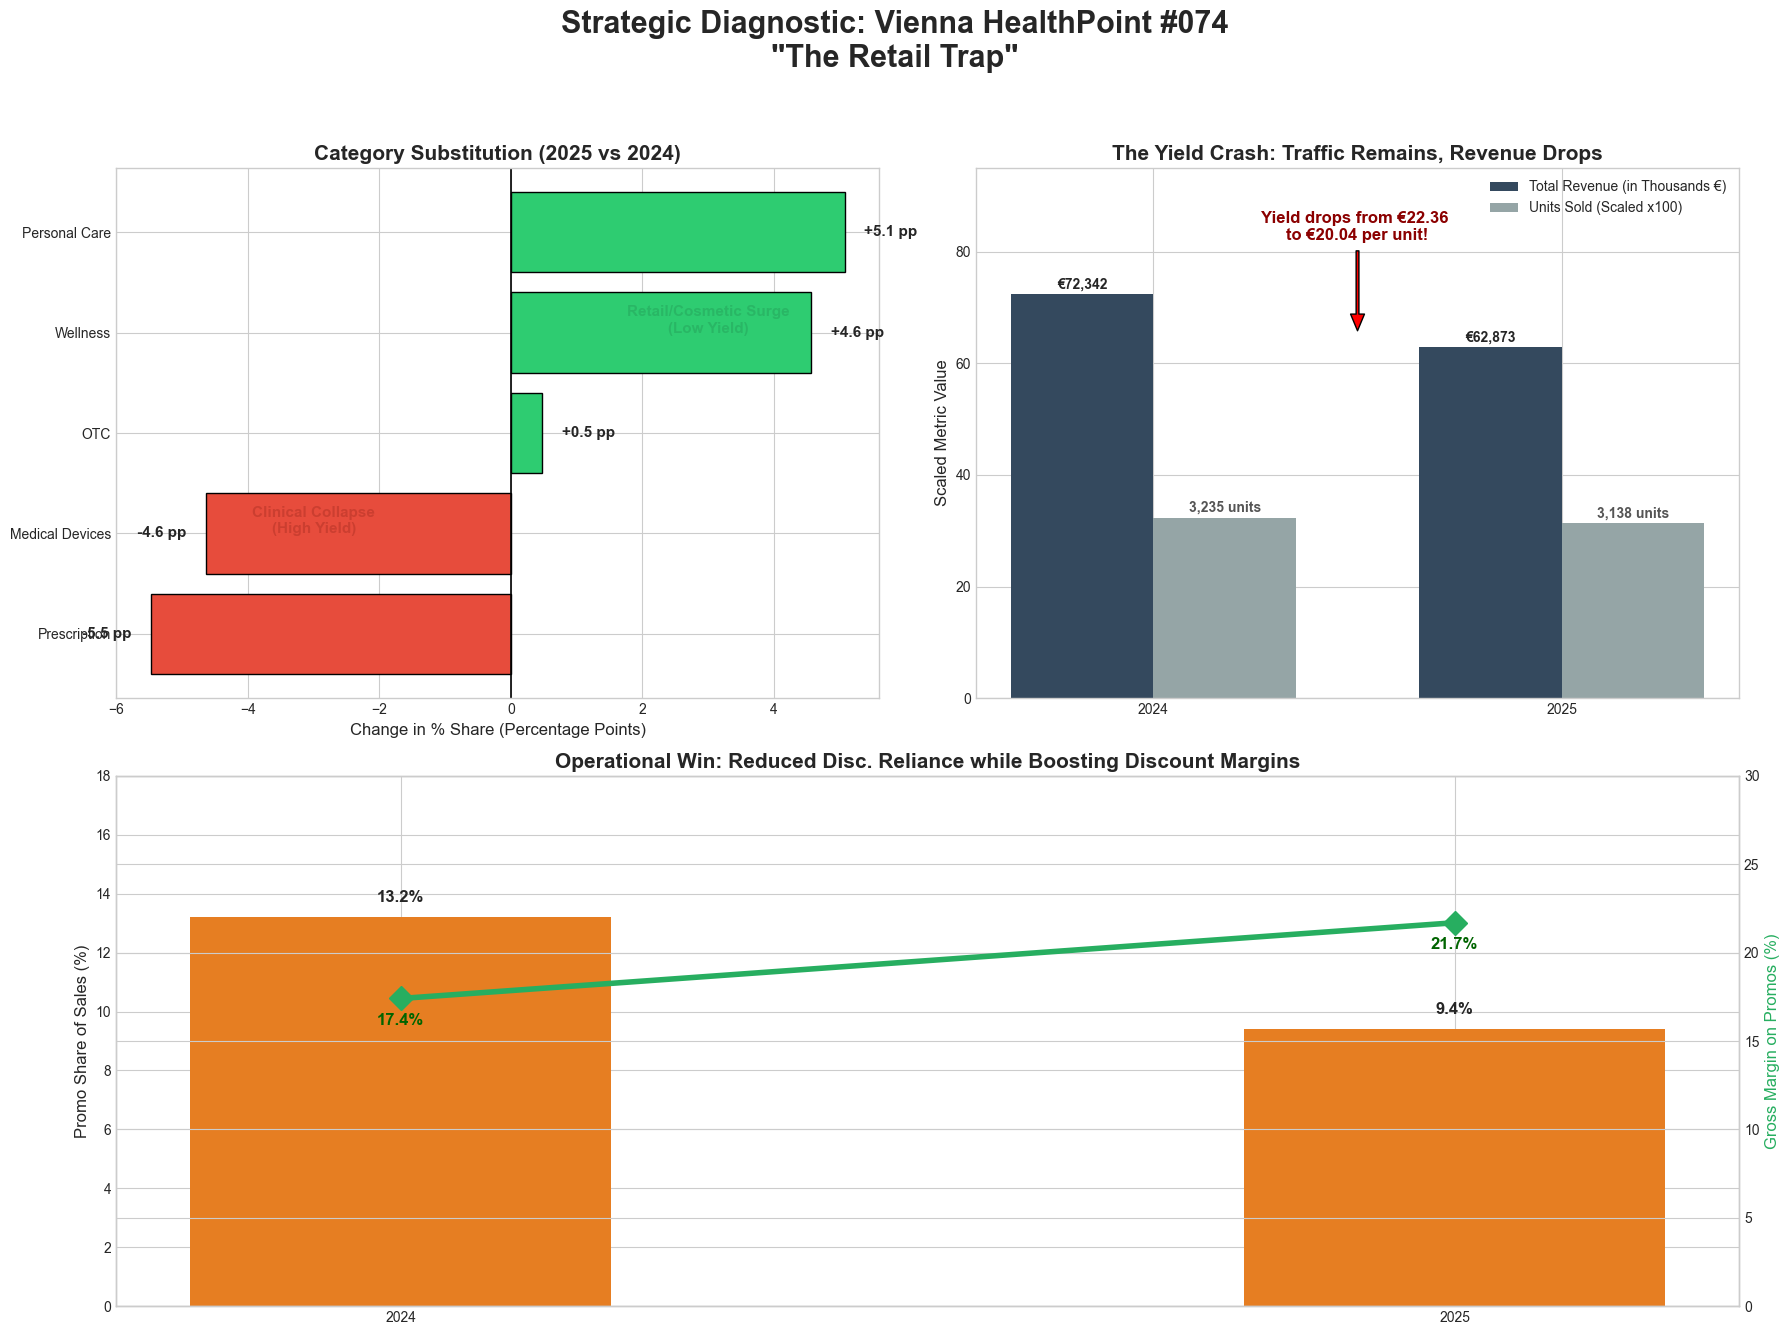

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming your DataFrame 'df' is loaded
pharmacy_name = 'Vienna HealthPoint #074'
df_p = df[df['PharmacyName'] == pharmacy_name].copy()

# Ensure 'Year' column exists
if 'Year' not in df_p.columns and 'DateKey' in df_p.columns:
    df_p['Year'] = df_p['DateKey'].astype(str).str[:4].astype(int)

# Set the overall style for a professional corporate look
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 14))
fig.suptitle(f'Strategic Diagnostic: {pharmacy_name}\n"The Retail Trap"', fontsize=22, fontweight='bold', y=0.98)

# ==========================================
# CHART 1: The "Retail Trap" Substitution (Mix Shift)
# ==========================================
ax1 = plt.subplot(2, 2, 1)

# Calculate % Share by Category for each year
cat_pivot = df_p.groupby(['Year', 'Category'])['RevenueEUR'].sum().unstack(level=0).fillna(0)
cat_pivot['2024_%'] = (cat_pivot[2024] / cat_pivot[2024].sum()) * 100
cat_pivot['2025_%'] = (cat_pivot[2025] / cat_pivot[2025].sum()) * 100
cat_pivot['Delta_pp'] = cat_pivot['2025_%'] - cat_pivot['2024_%']

# Sort Categories from worst drops to biggest gains
cat_pivot = cat_pivot.sort_values(by='Delta_pp', ascending=True)

# Color negative shifts red (Clinical collapse), positive shifts green (Retail surge)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in cat_pivot['Delta_pp']]

ax1.barh(cat_pivot.index, cat_pivot['Delta_pp'], color=colors, edgecolor='black')
ax1.set_title('Category Substitution (2025 vs 2024)', fontsize=15, fontweight='bold')
ax1.set_xlabel('Change in % Share (Percentage Points)', fontsize=12)
ax1.axvline(0, color='black', linewidth=1.2)

# Annotated Context
ax1.text(-3, 1, 'Clinical Collapse\n(High Yield)', color='#c0392b', fontweight='bold', fontsize=11, ha='center', alpha=0.7)
ax1.text(3, 3, 'Retail/Cosmetic Surge\n(Low Yield)', color='#27ae60', fontweight='bold', fontsize=11, ha='center', alpha=0.7)

for i, (val, name) in enumerate(zip(cat_pivot['Delta_pp'], cat_pivot.index)):
    align = 'right' if val < 0 else 'left'
    padding = -0.3 if val < 0 else 0.3
    ax1.text(val + padding, i, f"{val:+.1f} pp", ha=align, va='center', fontweight='bold', fontsize=11)

# ==========================================
# CHART 2: Efficiency Disconnect (Units vs Revenue)
# ==========================================
# Since units sold hold steady but yield drops, revenue crashes.
ax2 = plt.subplot(2, 2, 2)

eff_data = []
for year in [2024, 2025]:
    df_y = df_p[df_p['Year'] == year]
    rev = df_y['RevenueEUR'].sum()
    units = df_y['UnitsSold'].sum()
    yield_unit = rev / units if units > 0 else 0
    eff_data.append({'Year': str(year), 'Revenue (€)': rev, 'Units Sold': units, 'Yield (€)': yield_unit})

eff_df = pd.DataFrame(eff_data)

x = np.arange(2)
width = 0.35

ax2.bar(x - width/2, eff_df['Revenue (€)']/1000, width, label='Total Revenue (in Thousands €)', color='#34495e')
ax2.bar(x + width/2, eff_df['Units Sold']/100, width, label='Units Sold (Scaled x100)', color='#95a5a6')

ax2.set_title('The Yield Crash: Traffic Remains, Revenue Drops', fontsize=15, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(eff_df['Year'])
ax2.set_ylabel('Scaled Metric Value', fontsize=12)

# Set an explicit Y-limit to give the annotation plenty of headroom under the title!
ax2.set_ylim(0, 95)
ax2.legend(loc='upper right')

# Annotate values above the bars
for i in range(2):
    ax2.text(i - width/2, (eff_df['Revenue (€)'].iloc[i]/1000) + 1, f"€{eff_df['Revenue (€)'].iloc[i]:,.0f}", ha='center', fontweight='bold')
    ax2.text(i + width/2, (eff_df['Units Sold'].iloc[i]/100) + 1, f"{eff_df['Units Sold'].iloc[i]:,.0f} units", ha='center', fontweight='bold', color='#555555')

# The Red Yield Call-out (adjusted xytext positioning so it sits freely)
ax2.annotate(f"Yield drops from €22.36 \nto €20.04 per unit!", 
            xy=(0.5, 65),     # Point of the arrow
            xytext=(0.5, 82), # Point where the text floats
            arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=10),
            ha='center', fontsize=12, fontweight='bold', color='darkred')



# ==========================================
# CHART 3: Promotional Rescue (Promo Share vs. Promo Margin)
# ==========================================
ax3 = plt.subplot(2, 1, 2)

promo_data = []
for year in [2024, 2025]:
    df_yr = df_p[df_p['Year'] == year]
    total_rev = df_yr['RevenueEUR'].sum()
    promo_df = df_yr[df_yr['PromoFlag'] == 'Yes']
    
    promo_rev = promo_df['RevenueEUR'].sum()
    promo_margin_eur = promo_df['MarginEUR'].sum()
    
    promo_share = (promo_rev / total_rev) * 100 if total_rev > 0 else 0
    promo_margin_pct = (promo_margin_eur / promo_rev) * 100 if promo_rev > 0 else 0
    
    promo_data.append({'Year': str(year), 'Promo Share %': promo_share, 'Promo Margin %': promo_margin_pct})

promo_df = pd.DataFrame(promo_data)

# Dual-axis chart
ax3.bar(promo_df['Year'], promo_df['Promo Share %'], color='#e67e22', width=0.4, label='Promo Share of Total Revenue')
ax3.set_ylabel('Promo Share of Sales (%)', fontsize=12)
ax3.set_ylim(0, 18) 

ax3_twin = ax3.twinx()
ax3_twin.plot(promo_df['Year'], promo_df['Promo Margin %'], color='#27ae60', marker='D', markersize=12, linewidth=4, label='Promo Gross Margin %')
ax3_twin.set_ylabel('Gross Margin on Promos (%)', fontsize=12, color='#27ae60')
ax3_twin.set_ylim(0, 30)

ax3.set_title('Operational Win: Reduced Disc. Reliance while Boosting Discount Margins', fontsize=15, fontweight='bold')

# Labels
for i, val in enumerate(promo_df['Promo Share %']):
    ax3.text(i, val + 0.5, f"{val:.1f}%", ha='center', fontweight='bold', fontsize=12)

for i, val in enumerate(promo_df['Promo Margin %']):
    ax3_twin.text(i, val - 1.5, f"{val:.1f}%", ha='center', color='darkgreen', fontweight='bold', fontsize=12)


# Layout adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


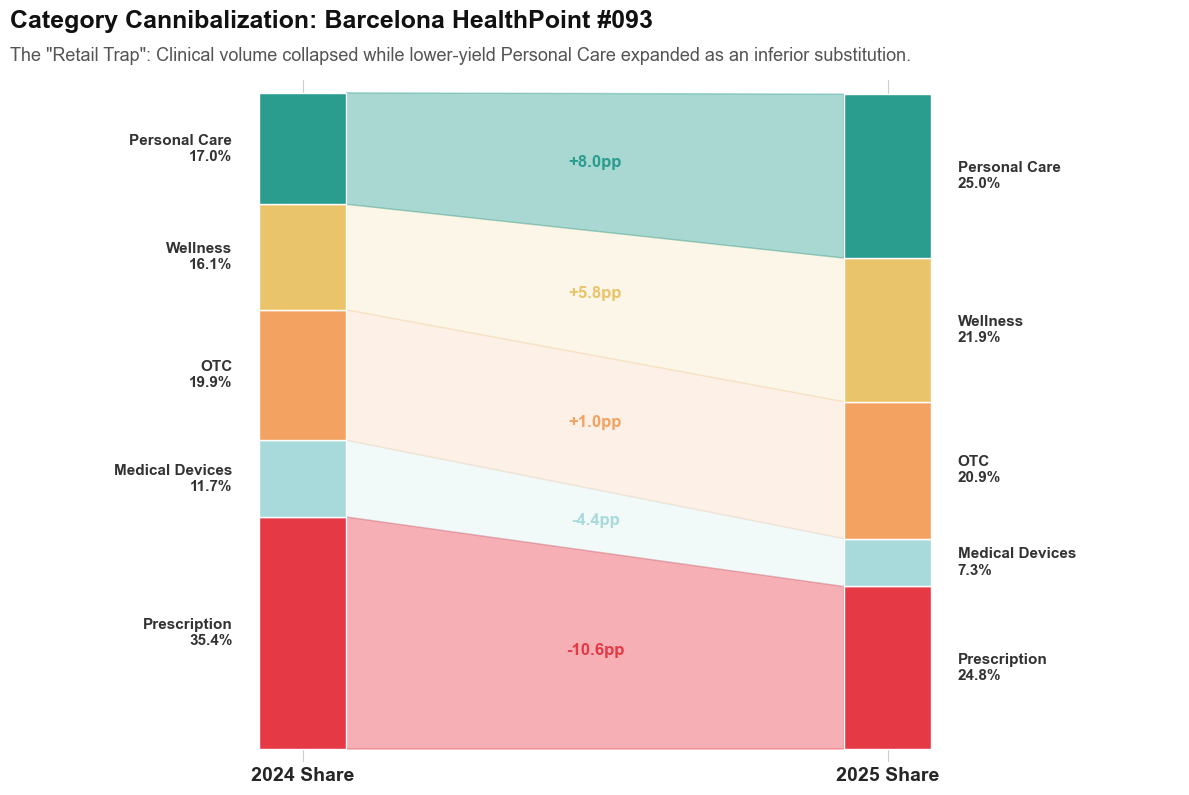

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Data from Barcelona HealthPoint #093 Diagnostic
categories = ['Prescription', 'Medical Devices', 'OTC', 'Wellness', 'Personal Care']
year_2024 = np.array([35.4, 11.7, 19.9, 16.1, 17.0])
year_2025 = np.array([24.8, 7.3, 20.9, 21.9, 25.0])

# Configure the figure
fig, ax = plt.subplots(figsize=(12, 8))

# Explicit coloring to highlight the insight:
# Red for shrinking medical/clinical, Teal/Blue for expanding retail shadow
colors = ['#E63946', '#A8DADC', '#F4A261', '#E9C46A', '#2A9D8F']

# Calculate cumulative sums for stacking (bottoms of the bars)
y_bot_24 = np.zeros(len(categories))
y_bot_25 = np.zeros(len(categories))

width = 0.15 # Width of the bars at x=0 and x=1

for i, cat in enumerate(categories):
    v24, v25 = year_2024[i], year_2025[i]
    
    # 2. Draw the vertical bars for 2024 and 2025
    ax.bar(0, v24, bottom=y_bot_24[i], width=width, color=colors[i], edgecolor='white', zorder=3)
    ax.bar(1, v25, bottom=y_bot_25[i], width=width, color=colors[i], edgecolor='white', zorder=3)
    
    # 3. Draw the "expanding/shrinking shadow" ribbons connecting the years
    # Coordinates: [Top Left, Top Right, Bottom Right, Bottom Left]
    x_poly = [width/2, 1 - width/2, 1 - width/2, width/2]
    y_poly = [
        y_bot_24[i] + v24, y_bot_25[i] + v25, 
        y_bot_25[i], y_bot_24[i]
    ]
    
    # Emphasize Prescription and Personal Care shadows, lower opacity for others
    alpha_shadow = 0.4 if cat in ['Prescription', 'Personal Care'] else 0.15
    ax.fill(x_poly, y_poly, color=colors[i], alpha=alpha_shadow, zorder=2)
    
    # 4. Add dynamic text labels showing the cannibalization
    # Label left (2024)
    ax.text(-width*0.8, y_bot_24[i] + v24/2, f"{cat}\n{v24}%", 
            va='center', ha='right', color='#333', fontsize=11, fontweight='bold')
    
    # Label right (2025)
    ax.text(1 + width*0.8, y_bot_25[i] + v25/2, f"{cat}\n{v25}%", 
            va='center', ha='left', color='#333', fontsize=11, fontweight='bold')
    
    # Annotate absolute point change
    delta = v25 - v24
    sign = "+" if delta > 0 else ""
    ax.text(0.5, (y_bot_24[i] + v24/2 + y_bot_25[i] + v25/2) / 2, 
            f"{sign}{delta:.1f}pp", va='center', ha='center', 
            color=colors[i], fontsize=12, fontweight='bold')

    # Advance bottom heights for the next stack segment
    y_bot_24 += v24
    y_bot_25 += v25

# 5. Clean up chart aesthetics
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-2, 102)
ax.set_xticks([0, 1])
ax.set_xticklabels(['2024 Share', '2025 Share'], fontsize=14, fontweight='bold')
ax.set_yticks([]) 

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Add titles
plt.text(-0.5, 110, 'Category Cannibalization: Barcelona HealthPoint #093', 
         fontsize=18, fontweight='bold', color='#111')
plt.text(-0.5, 105, 'The "Retail Trap": Clinical volume collapsed while lower-yield Personal Care expanded as an inferior substitution.', 
         fontsize=13, color='#555')

plt.tight_layout()
plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_3940\1641049531.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


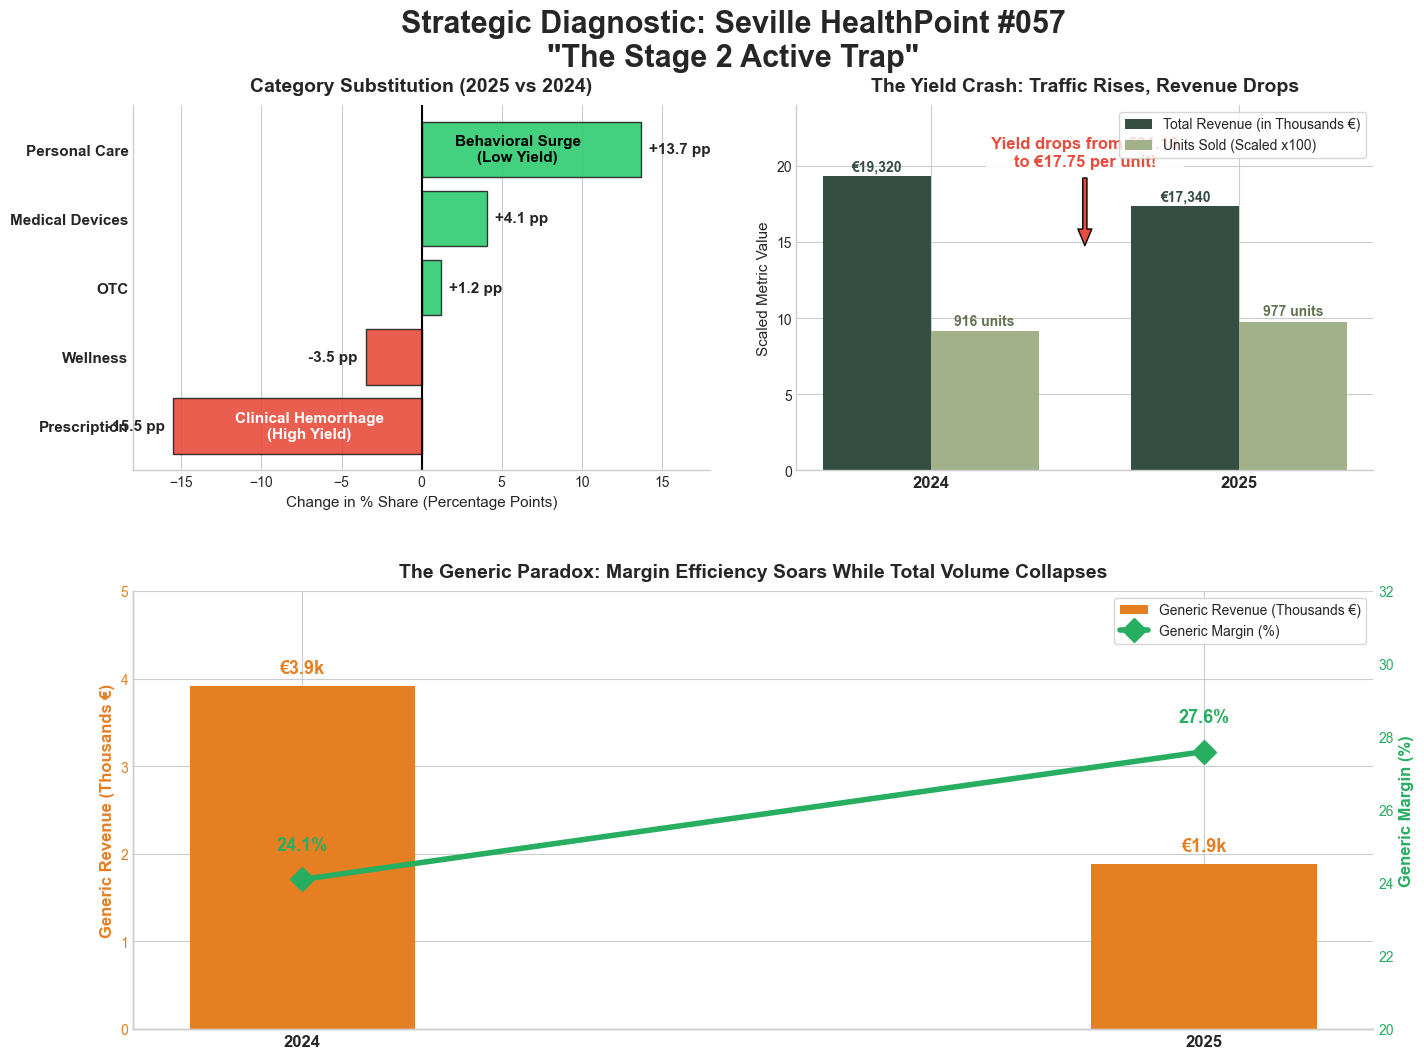

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# --- SEVILLE #057 DATA ---
# 1. Category Substitution
categories = ['Personal Care', 'Medical Devices', 'OTC', 'Wellness', 'Prescription']
deltas = [13.7, 4.1, 1.2, -3.5, -15.5]

# 2. Revenue vs Volume (Busy but Broke)
years = ['2024', '2025']
rev_k = [19.32, 17.34]        # Total Revenue in Thousands
units_scaled = [9.16, 9.77]   # Units Sold scaled to fit (Units / 100)

# 3. Generic Dynamics
gen_rev = [3.91, 1.88]        # Generic Revenue in Thousands
gen_margin = [24.1, 27.6]     # Generic Margin %

# --- SETUP FIGURE AND GRID ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.3, wspace=0.15)

fig.suptitle('Strategic Diagnostic: Seville HealthPoint #057\n"The Stage 2 Active Trap"', 
             fontsize=22, fontweight='bold', y=0.96)


# ==========================================
# PANE 1: CATEGORY SUBSTITUTION (Top-Left)
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
y_pos = np.arange(len(categories))
colors_bar = ['#2ECC71' if x > 0 else '#E74C3C' for x in deltas]

ax1.barh(y_pos, deltas, color=colors_bar, edgecolor='#222', alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories, fontsize=11, fontweight='bold')
ax1.invert_yaxis() # Put Personal Care at the top, Prescription at bottom
ax1.axvline(0, color='black', linewidth=1.5)

ax1.set_title('Category Substitution (2025 vs 2024)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Change in % Share (Percentage Points)', fontsize=11)
ax1.set_xlim(-18, 18)
ax1.grid(axis='y', alpha=0) 

# Inner Bar annotations
for i, v in enumerate(deltas):
    if v < 0:
        ax1.text(v - 0.5, i, f"{v} pp", va='center', ha='right', fontweight='bold', fontsize=11)
    else:
        ax1.text(v + 0.5, i, f"+{v} pp", va='center', ha='left', fontweight='bold', fontsize=11)

# Strategic Labels inside the massive bars
ax1.text(-7, 4, "Clinical Hemorrhage\n(High Yield)", ha='center', va='center', color='white', fontweight='bold', fontsize=11)
ax1.text(6, 0, "Behavioral Surge\n(Low Yield)", ha='center', va='center', color='black', fontweight='bold', fontsize=11)


# ==========================================
# PANE 2: THE YIELD CRASH (Top-Right)
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(years))
width = 0.35

rects1 = ax2.bar(x - width/2, rev_k, width, label='Total Revenue (in Thousands €)', color='#344E41')
rects2 = ax2.bar(x + width/2, units_scaled, width, label='Units Sold (Scaled x100)', color='#A3B18A')

ax2.set_title('The Yield Crash: Traffic Rises, Revenue Drops', fontsize=14, fontweight='bold', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=12, fontweight='bold')
ax2.set_ylabel('Scaled Metric Value', fontsize=11)
ax2.set_ylim(0, 24)
ax2.legend(loc='upper right', frameon=True)

# Value Labels
for i, v in enumerate(rev_k):
    ax2.text(i - width/2, v + 0.4, f"€{v*1000:,.0f}", ha='center', fontweight='bold', color='#344E41')
for i, v in enumerate(units_scaled):
    ax2.text(i + width/2, v + 0.4, f"{int(v*100):,} units", ha='center', fontweight='bold', color='#637351')

# The Red Flag Arrow
ax2.annotate('Yield drops from €21.10\nto €17.75 per unit!', 
             xy=(0.5, 14.5), xytext=(0.5, 20),
             arrowprops=dict(facecolor='#E74C3C', shrink=0.05, width=3, headwidth=10),
             ha='center', fontsize=12, fontweight='bold', color='#E74C3C',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9))


# ==========================================
# PANE 3: GENERIC PARADOX (Bottom)
# ==========================================
ax3 = fig.add_subplot(gs[1, :])

width3 = 0.25
color_gen_rev = '#E67E22'  # Orange for Revenue collapse
# Bar Chart for Collapsing Revenue
ax3.bar(x, gen_rev, width=width3, color=color_gen_rev, label='Generic Revenue (Thousands €)')
ax3.set_ylabel('Generic Revenue (Thousands €)', color=color_gen_rev, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_gen_rev)
ax3.set_xticks(x)
ax3.set_xticklabels(years, fontsize=12, fontweight='bold')
ax3.set_ylim(0, 5)

for i, v in enumerate(gen_rev):
    ax3.text(i, v + 0.15, f"€{v:,.1f}k", ha='center', color=color_gen_rev, fontweight='bold', fontsize=13)

# Line Chart for Rising Margin
ax4 = ax3.twinx()
color_gen_margin = '#27AE60' # Green for Margin rise
ax4.plot(years, gen_margin, color=color_gen_margin, linewidth=4, marker='D', markersize=12, label='Generic Margin (%)')
ax4.set_ylabel('Generic Margin (%)', color=color_gen_margin, fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=color_gen_margin)
ax4.set_ylim(20, 32)
ax4.grid(False)

for i, v in enumerate(gen_margin):
    # Offset the text slightly so it doesn't overlap the diamond marker
    ax4.text(years[i], v + 0.8, f"{v}%", ha='center', color=color_gen_margin, fontweight='bold', fontsize=13)

ax3.set_title('The Generic Paradox: Margin Efficiency Soars While Total Volume Collapses', fontsize=14, fontweight='bold', pad=10)

# Final Clean Up
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add combined legend for the bottom pane
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax4.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_3940\937648605.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


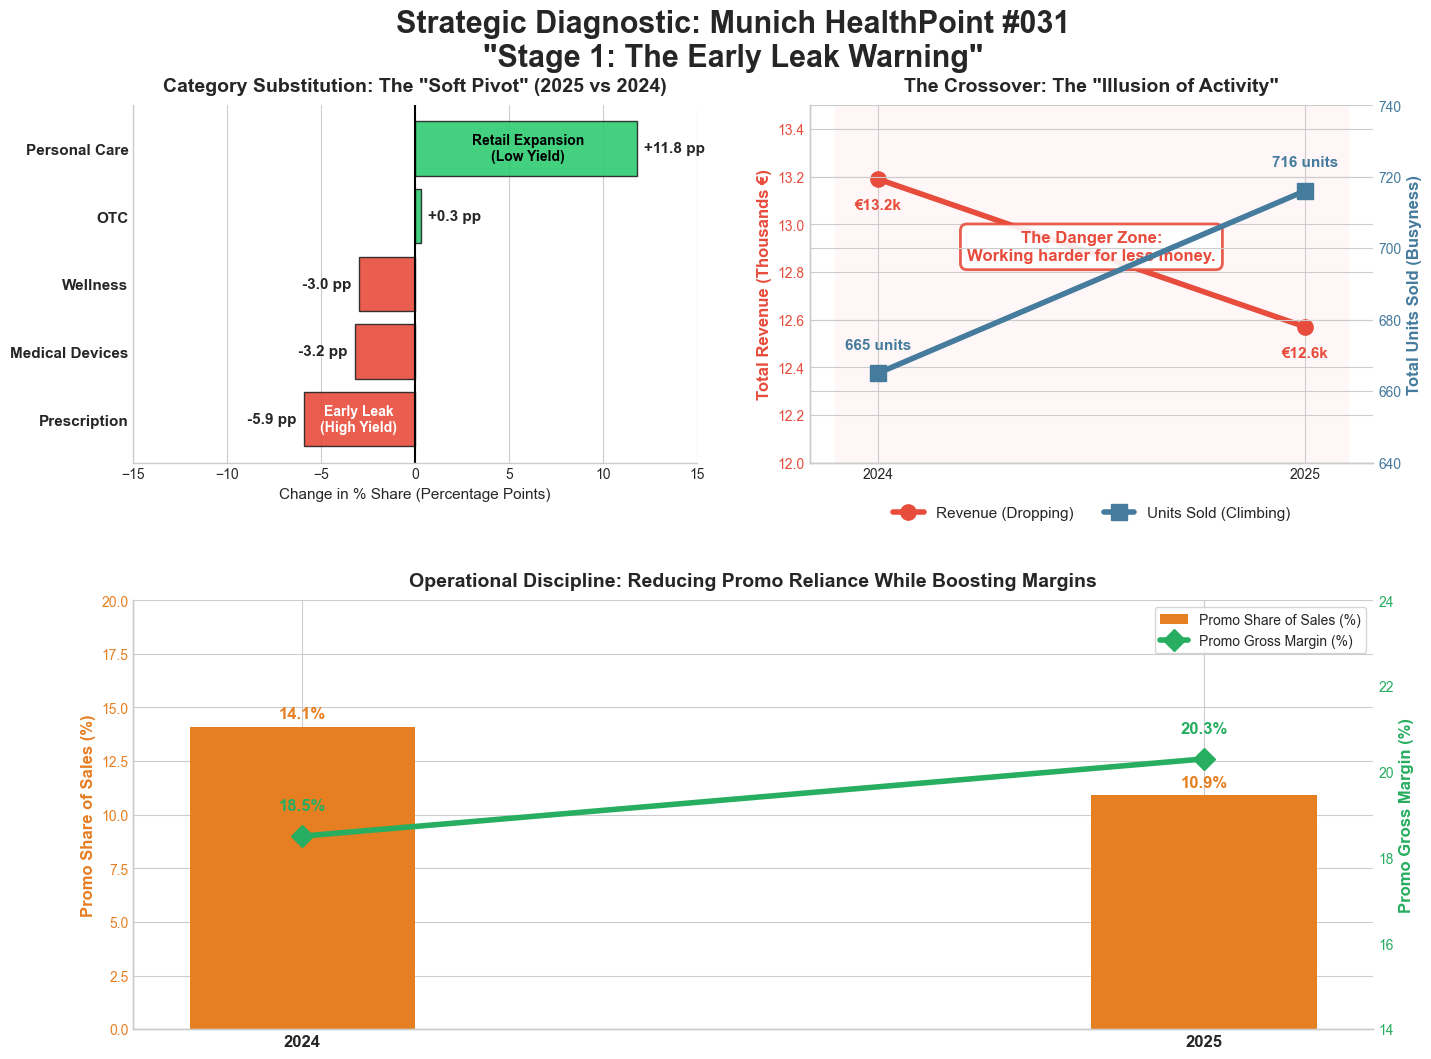

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# --- MUNICH #031 DATA ---
# 1. Category Substitution (Delta pp)
categories = ['Personal Care', 'OTC', 'Wellness', 'Medical Devices', 'Prescription']
deltas = [11.8, 0.3, -3.0, -3.2, -5.9]

# 2. The Crossover: Revenue vs Volume
years = ['2024', '2025']
rev_k = [13.19, 12.57]        # Total Revenue in Thousands (€)
units = [665, 716]            # Total Units Sold

# 3. Promotional Discipline
promo_share = [14.1, 10.9]    # Promo Share of Revenue (%)
promo_margin = [18.5, 20.3]   # Promo Items Gross Margin (%)

# --- SETUP FIGURE AND GRID ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.2)

fig.suptitle('Strategic Diagnostic: Munich HealthPoint #031\n"Stage 1: The Early Leak Warning"', 
             fontsize=22, fontweight='bold', y=0.96)


# ==========================================
# PANE 1: THE SOFT SUBSTITUTION (Top-Left)
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
y_pos = np.arange(len(categories))
colors_bar = ['#2ECC71' if x > 0 else '#E74C3C' for x in deltas]

ax1.barh(y_pos, deltas, color=colors_bar, edgecolor='#222', alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories, fontsize=11, fontweight='bold')
ax1.invert_yaxis() # Put Personal care at top
ax1.axvline(0, color='black', linewidth=1.5)

ax1.set_title('Category Substitution: The "Soft Pivot" (2025 vs 2024)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Change in % Share (Percentage Points)', fontsize=11)
ax1.set_xlim(-15, 15)
ax1.grid(axis='y', alpha=0) 

# Highlight Text
ax1.text(-3.0, 4, "Early Leak\n(High Yield)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
ax1.text(6.0, 0, "Retail Expansion\n(Low Yield)", ha='center', va='center', color='black', fontweight='bold', fontsize=10)

for i, v in enumerate(deltas):
    if v < 0:
        ax1.text(v - 0.4, i, f"{v} pp", va='center', ha='right', fontweight='bold', fontsize=11)
    else:
        ax1.text(v + 0.4, i, f"+{v} pp", va='center', ha='left', fontweight='bold', fontsize=11)


# ==========================================
# PANE 2: THE CROSSOVER DANGER ZONE (Top-Right)
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])
color_rev = '#E74C3C'  # Red for dropping revenue
color_vol = '#457B9D'  # Blue for rising volume

# Revenue Line (Left Axis)
ax2.set_ylabel('Total Revenue (Thousands €)', color=color_rev, fontsize=12, fontweight='bold')
line1 = ax2.plot(years, rev_k, color=color_rev, marker='o', markersize=11, linewidth=4, label='Revenue (Dropping)')
ax2.tick_params(axis='y', labelcolor=color_rev)
ax2.set_ylim(12.0, 13.5)

# Volume Line (Right Axis)
ax2a = ax2.twinx()
ax2a.set_ylabel('Total Units Sold (Busyness)', color=color_vol, fontsize=12, fontweight='bold')
line2 = ax2a.plot(years, units, color=color_vol, marker='s', markersize=11, linewidth=4, label='Units Sold (Climbing)')
ax2a.tick_params(axis='y', labelcolor=color_vol)
ax2a.set_ylim(640, 740)

ax2.set_title('The Crossover: The "Illusion of Activity"', fontsize=14, fontweight='bold', pad=10)

# Danger Zone Annotation
ax2.axvspan(-0.1, 1.1, color='#ffe6e6', alpha=0.3, zorder=-1)
ax2.annotate('The Danger Zone:\nWorking harder for less money.', 
             xy=(0.5, 12.85), xycoords='data',
             ha='center', fontsize=12, fontweight='bold', color='#E74C3C',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#E74C3C", lw=2, alpha=0.9))

# Labels
for i, v in enumerate(rev_k):
    ax2.text(years[i], v - 0.08, f"€{v:,.1f}k", ha='center', va='top', fontweight='bold', color=color_rev, fontsize=11)
for i, v in enumerate(units):
    ax2a.text(years[i], v + 6, f"{v} units", ha='center', va='bottom', fontweight='bold', color=color_vol, fontsize=11)

# Combined Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False, fontsize=11)


# ==========================================
# PANE 3: PROMOTIONAL DISCIPLINE (Bottom)
# ==========================================
ax3 = fig.add_subplot(gs[1, :])
x_bot = np.arange(len(years))
width3 = 0.25

color_promo = '#E67E22'  # Orange for Promo Reliance 
ax3.bar(x_bot, promo_share, width=width3, color=color_promo, label='Promo Share of Sales (%)')
ax3.set_ylabel('Promo Share of Sales (%)', color=color_promo, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_promo)
ax3.set_xticks(x_bot)
ax3.set_xticklabels(years, fontsize=12, fontweight='bold')
ax3.set_ylim(0, 20)

for i, v in enumerate(promo_share):
    ax3.text(i, v + 0.4, f"{v}%", ha='center', color=color_promo, fontweight='bold', fontsize=12)

color_margin = '#27AE60' # Green for Margin health
ax4 = ax3.twinx()
ax4.plot(years, promo_margin, color=color_margin, linewidth=4, marker='D', markersize=11, label='Promo Gross Margin (%)')
ax4.set_ylabel('Promo Gross Margin (%)', color=color_margin, fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=color_margin)
ax4.set_ylim(14, 24)
ax4.grid(False)

for i, v in enumerate(promo_margin):
    ax4.text(years[i], v + 0.6, f"{v}%", ha='center', color=color_margin, fontweight='bold', fontsize=12)

ax3.set_title('Operational Discipline: Reducing Promo Reliance While Boosting Margins', fontsize=14, fontweight='bold', pad=10)

# Final Spines & combined legend
for ax in [ax1, ax2, ax2a, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_3940\3583468059.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


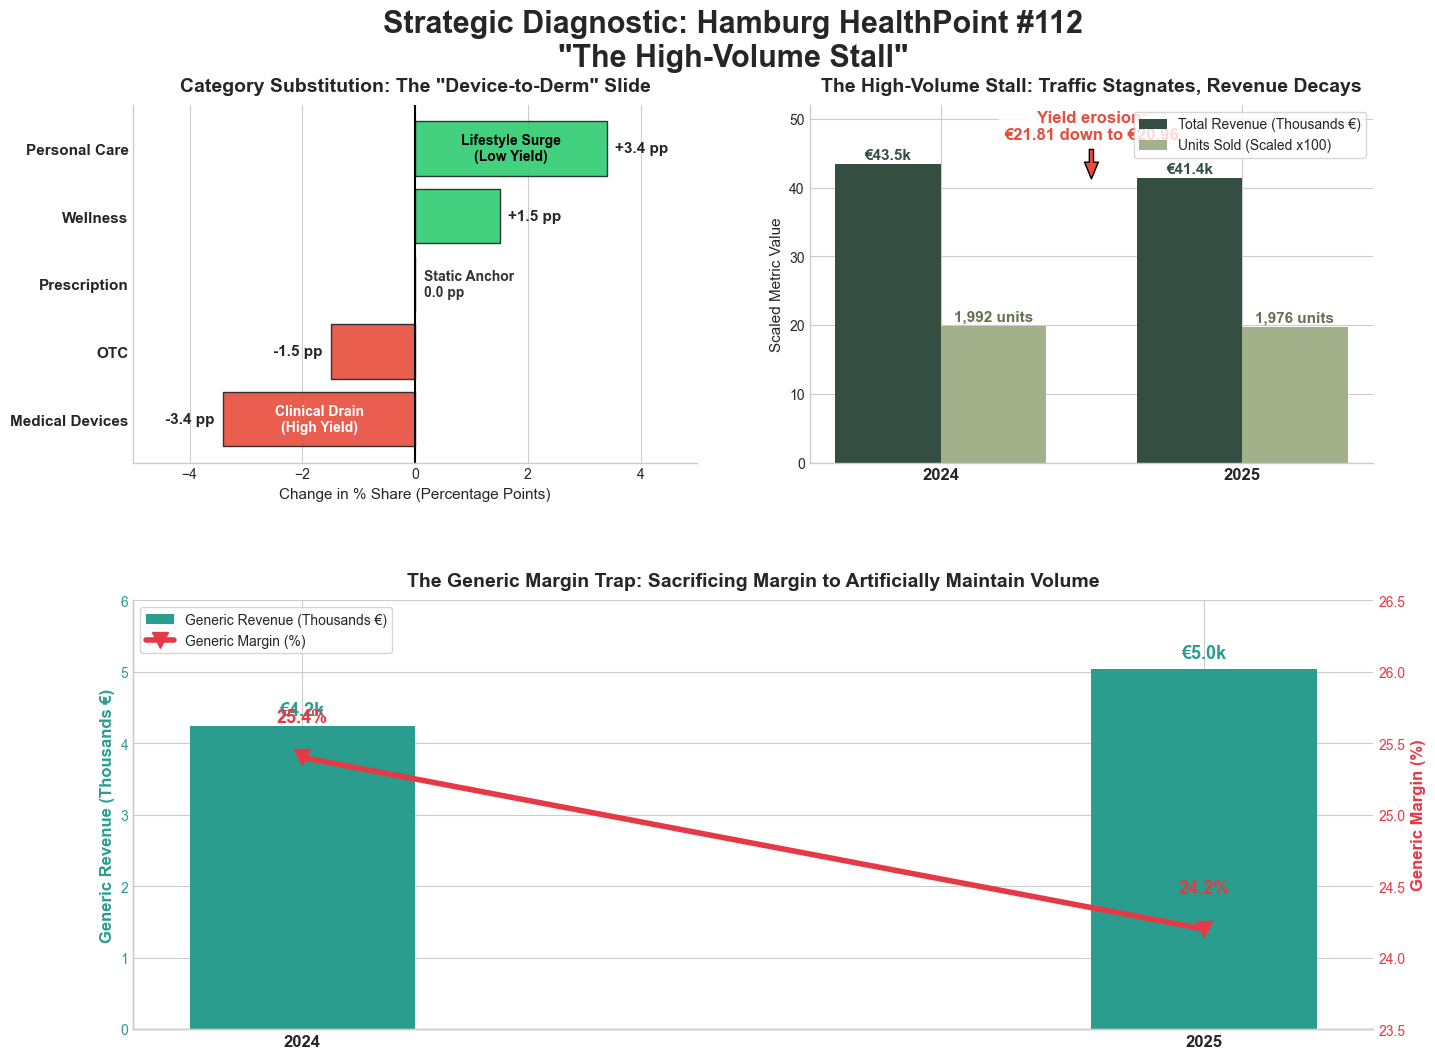

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# --- HAMBURG #112 DATA ---
# 1. Category Substitution (Delta pp)
categories = ['Personal Care', 'Wellness', 'Prescription', 'OTC', 'Medical Devices']
deltas = [3.4, 1.5, 0.0, -1.5, -3.4]

# 2. Revenue vs Volume (The Stall)
years = ['2024', '2025']
rev_k = [43.45, 41.42]        # Total Revenue in Thousands (€)
units_scaled = [19.92, 19.76] # Total Units Sold (Scaled x100)

# 3. The Generic Price War
gen_rev = [4.24, 5.04]        # Generic Revenue in Thousands (€)
gen_margin = [25.4, 24.2]     # Generic Margin (%)

# --- SETUP FIGURE AND GRID ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.2)

fig.suptitle('Strategic Diagnostic: Hamburg HealthPoint #112\n"The High-Volume Stall"', 
             fontsize=22, fontweight='bold', y=0.96)


# ==========================================
# PANE 1: THE DEVICE-TO-DERM SLIDE (Top-Left)
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
y_pos = np.arange(len(categories))

# Color coding: Green (Growth), Red (Decline), Gray (Static Anchor)
colors_bar = []
for x in deltas:
    if x > 0.1: colors_bar.append('#2ECC71')
    elif x < -0.1: colors_bar.append('#E74C3C')
    else: colors_bar.append('#7F8C8D')

ax1.barh(y_pos, deltas, color=colors_bar, edgecolor='#222', alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories, fontsize=11, fontweight='bold')
ax1.invert_yaxis() # Top to bottom
ax1.axvline(0, color='black', linewidth=1.5)

ax1.set_title('Category Substitution: The "Device-to-Derm" Slide', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Change in % Share (Percentage Points)', fontsize=11)
ax1.set_xlim(-5, 5)
ax1.grid(axis='y', alpha=0)

# Strategic Inner Tags
ax1.text(1.7, 0, "Lifestyle Surge\n(Low Yield)", ha='center', va='center', color='black', fontweight='bold', fontsize=10)
ax1.text(-1.7, 4, "Clinical Drain\n(High Yield)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

for i, v in enumerate(deltas):
    if v < 0:
        ax1.text(v - 0.15, i, f"{v} pp", va='center', ha='right', fontweight='bold', fontsize=11)
    elif v > 0:
        ax1.text(v + 0.15, i, f"+{v} pp", va='center', ha='left', fontweight='bold', fontsize=11)
    else:
        ax1.text(0.15, i, f"Static Anchor\n{v} pp", va='center', ha='left', fontweight='bold', color='#333', fontsize=10)


# ==========================================
# PANE 2: THE HIGH-VOLUME STALL (Top-Right)
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(years))
width = 0.35

rects1 = ax2.bar(x - width/2, rev_k, width, label='Total Revenue (Thousands €)', color='#344E41')
rects2 = ax2.bar(x + width/2, units_scaled, width, label='Units Sold (Scaled x100)', color='#A3B18A')

ax2.set_title('The High-Volume Stall: Traffic Stagnates, Revenue Decays', fontsize=14, fontweight='bold', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=12, fontweight='bold')
ax2.set_ylabel('Scaled Metric Value', fontsize=11)
ax2.set_ylim(0, 52)
ax2.legend(loc='upper right', frameon=True)

for i, v in enumerate(rev_k):
    ax2.text(i - width/2, v + 0.7, f"€{v:,.1f}k", ha='center', fontweight='bold', color='#344E41', fontsize=11)
for i, v in enumerate(units_scaled):
    ax2.text(i + width/2, v + 0.7, f"{int(v*100):,} units", ha='center', fontweight='bold', color='#637351', fontsize=11)

# Highlight Yield Erosion
ax2.annotate('Yield erosion:\n€21.81 down to €20.96', 
             xy=(0.5, 41), xytext=(0.5, 47),
             arrowprops=dict(facecolor='#E74C3C', shrink=0.05, width=3, headwidth=10),
             ha='center', fontsize=12, fontweight='bold', color='#E74C3C',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9))


# ==========================================
# PANE 3: THE GENERIC PRICE WAR (Bottom)
# ==========================================
ax3 = fig.add_subplot(gs[1, :])
x_bot = np.arange(len(years))

color_gen_rev = '#2A9D8F'  # Teal for Generic Revenue surge
ax3.bar(x_bot, gen_rev, width=0.25, color=color_gen_rev, label='Generic Revenue (Thousands €)')
ax3.set_ylabel('Generic Revenue (Thousands €)', color=color_gen_rev, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_gen_rev)
ax3.set_xticks(x_bot)
ax3.set_xticklabels(years, fontsize=12, fontweight='bold')
ax3.set_ylim(0, 6)

for i, v in enumerate(gen_rev):
    ax3.text(i, v + 0.15, f"€{v:,.1f}k", ha='center', color=color_gen_rev, fontweight='bold', fontsize=13)

color_margin = '#E63946' # Red for Margin Drop
ax4 = ax3.twinx()
ax4.plot(years, gen_margin, color=color_margin, linewidth=4, marker='v', markersize=12, label='Generic Margin (%)')
ax4.set_ylabel('Generic Margin (%)', color=color_margin, fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=color_margin)
ax4.set_ylim(23.5, 26.5)
ax4.grid(False)

# Offset label for red drop
for i, v in enumerate(gen_margin):
    ax4.text(years[i], v + 0.25, f"{v}%", ha='center', color=color_margin, fontweight='bold', fontsize=13)

ax3.set_title('The Generic Margin Trap: Sacrificing Margin to Artificially Maintain Volume', fontsize=14, fontweight='bold', pad=10)

# Final formatting
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_3940\405162297.py:46: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.annotate('The Clinical Vacuum\nMassive -17.1pp anchor collapse.',
C:\Users\adith\AppData\Local\Temp\ipykernel_3940\405162297.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


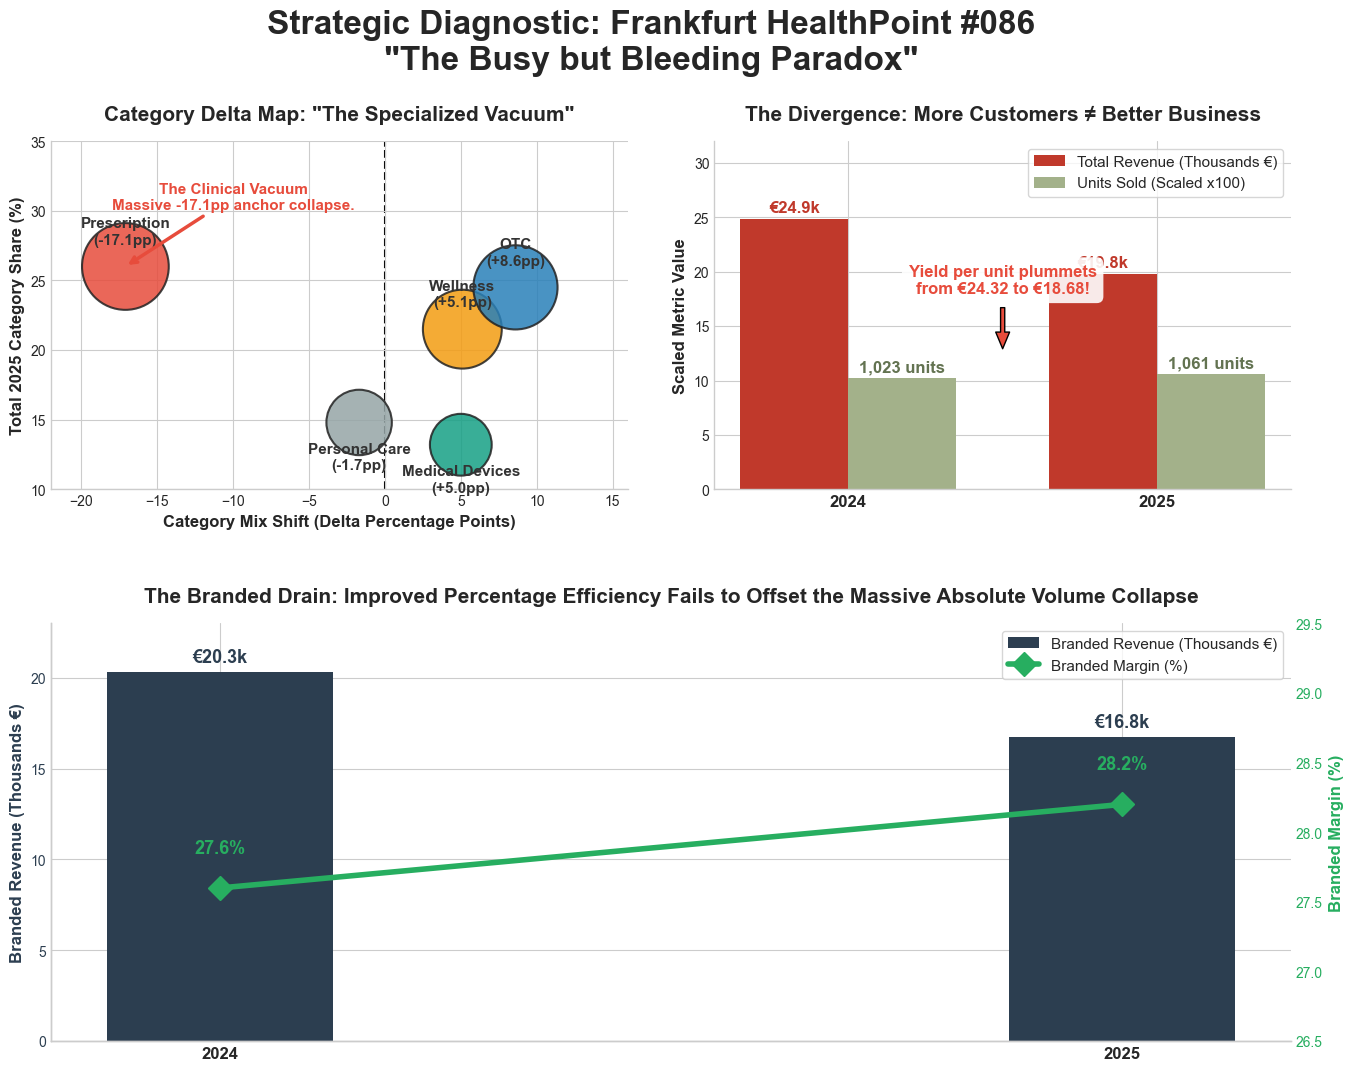

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# --- FRANKFURT #086 DATA ---
# 1. Delta Scatter Data (Top Left)
categories = ['Prescription', 'Personal Care', 'Medical Devices', 'Wellness', 'OTC']
delta_pp = [-17.1, -1.7, 5.0, 5.1, 8.6]
share_25 = [26.0, 14.8, 13.2, 21.5, 24.5]

# 2. Busy vs Bleeding Data (Top Right)
years = ['2024', '2025']
units = [1023, 1061]          # Units Sold
rev = [24.88, 19.82]          # Total Revenue (Thousands €)

# 3. The Branded Drain Data (Bottom)
brand_rev = [20.34, 16.76]    # Branded Revenue (Thousands €)
brand_margin = [27.6, 28.2]   # Branded Margin (%)

# --- SETUP FIGURE AND GRID ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.15)

# Positioned slightly higher
fig.suptitle('Strategic Diagnostic: Frankfurt HealthPoint #086\n"The Busy but Bleeding Paradox"', 
             fontsize=24, fontweight='bold', y=0.97)


# ==========================================
# PANE 1: THE DELTA SCATTER MAP (Top-Left)
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])

colors = ['#E74C3C', '#95A5A6', '#16A085', '#F39C12', '#2980B9'] 
sizes = [s * 150 for s in share_25]

scatter = ax1.scatter(delta_pp, share_25, s=sizes, c=colors, alpha=0.85, edgecolors='#222', linewidth=1.5)
ax1.axvline(0, color='black', linestyle='--', linewidth=1.5, zorder=0)

for i, cat in enumerate(categories):
    y_offset = 2.5 if share_25[i] > 18 else -2.5
    ax1.text(delta_pp[i], share_25[i] + y_offset, f"{cat}\n({delta_pp[i]:+.1f}pp)", 
             ha='center', va='center', fontweight='bold', fontsize=11, color='#333')

ax1.annotate('The Clinical Vacuum\nMassive -17.1pp anchor collapse.', 
             xy=(-17.1, 26.0), xytext=(-10, 31),
             arrowprops=dict(facecolor='#E74C3C', arrowstyle='->', lw=2.5, color='#E74C3C'),
             fontsize=11, fontweight='bold', color='#E74C3C', ha='center', va='center')

ax1.set_xlabel('Category Mix Shift (Delta Percentage Points)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total 2025 Category Share (%)', fontsize=12, fontweight='bold')
ax1.set_title('Category Delta Map: "The Specialized Vacuum"', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlim(-22, 16)
ax1.set_ylim(10, 35)


# ==========================================
# PANE 2: BUSY BUT BLEEDING (Top-Right)
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])

color_vol = '#A3B18A' 
color_rev = '#C0392B' 

x = np.arange(len(years))
width = 0.35

ax2.bar(x - width/2, rev, width, label='Total Revenue (Thousands €)', color=color_rev)
ax2.bar(x + width/2, [u/100 for u in units], width, label='Units Sold (Scaled x100)', color=color_vol)

ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=12, fontweight='bold')
ax2.set_ylabel('Scaled Metric Value', fontsize=12, fontweight='bold')
ax2.set_title('The Divergence: More Customers ≠ Better Business', fontsize=15, fontweight='bold', pad=15)

for i, v in enumerate(rev):
    ax2.text(i - width/2, v + 0.6, f"€{v:,.1f}k", ha='center', fontweight='bold', color=color_rev, fontsize=12)

for i, v in enumerate(units):
    ax2.text(i + width/2, (v/100) + 0.6, f"{v:,} units", ha='center', fontweight='bold', color='#637351', fontsize=12)

ax2.annotate('Yield per unit plummets\nfrom €24.32 to €18.68!', 
             xy=(0.5, 12.5), xytext=(0.5, 18),
             arrowprops=dict(facecolor='#E74C3C', shrink=0.08, width=3, headwidth=10),
             ha='center', fontsize=12, fontweight='bold', color='#E74C3C',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="none", alpha=0.9))

ax2.set_ylim(0, 32)
ax2.legend(loc='upper right', frameon=True, fontsize=11)


# ==========================================
# PANE 3: THE BRANDED DRAIN (Bottom)
# ==========================================
ax3 = fig.add_subplot(gs[1, :])

color_brand_rev = '#2C3E50' 
ax3.bar(x, brand_rev, width=0.25, color=color_brand_rev, label='Branded Revenue (Thousands €)')
ax3.set_ylabel('Branded Revenue (Thousands €)', color=color_brand_rev, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_brand_rev)
ax3.set_xticks(x)
ax3.set_xticklabels(years, fontsize=12, fontweight='bold')
ax3.set_ylim(0, 23)

for i, v in enumerate(brand_rev):
    ax3.text(i, v + 0.5, f"€{v:,.1f}k", ha='center', color=color_brand_rev, fontweight='bold', fontsize=13)

color_brand_margin = '#27AE60'
ax4 = ax3.twinx()
ax4.plot(years, brand_margin, color=color_brand_margin, linewidth=4, marker='D', markersize=12, label='Branded Margin (%)')
ax4.set_ylabel('Branded Margin (%)', color=color_brand_margin, fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=color_brand_margin)
ax4.set_ylim(26.5, 29.5)
ax4.grid(False)

for i, v in enumerate(brand_margin):
    ax4.text(years[i], v + 0.25, f"{v}%", ha='center', color=color_brand_margin, fontweight='bold', fontsize=13)

ax3.set_title('The Branded Drain: Improved Percentage Efficiency Fails to Offset the Massive Absolute Volume Collapse', 
              fontsize=15, fontweight='bold', pad=15)

# Final Clean Up
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper right', frameon=True, fontsize=11)

# ----- THE FIX -----
# We run tight_layout first to organize the subplots
plt.tight_layout()
# Then we explicitly force a massive top margin (0.86) to leave room for the headline!
fig.subplots_adjust(top=0.86)

plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_3940\3611378249.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


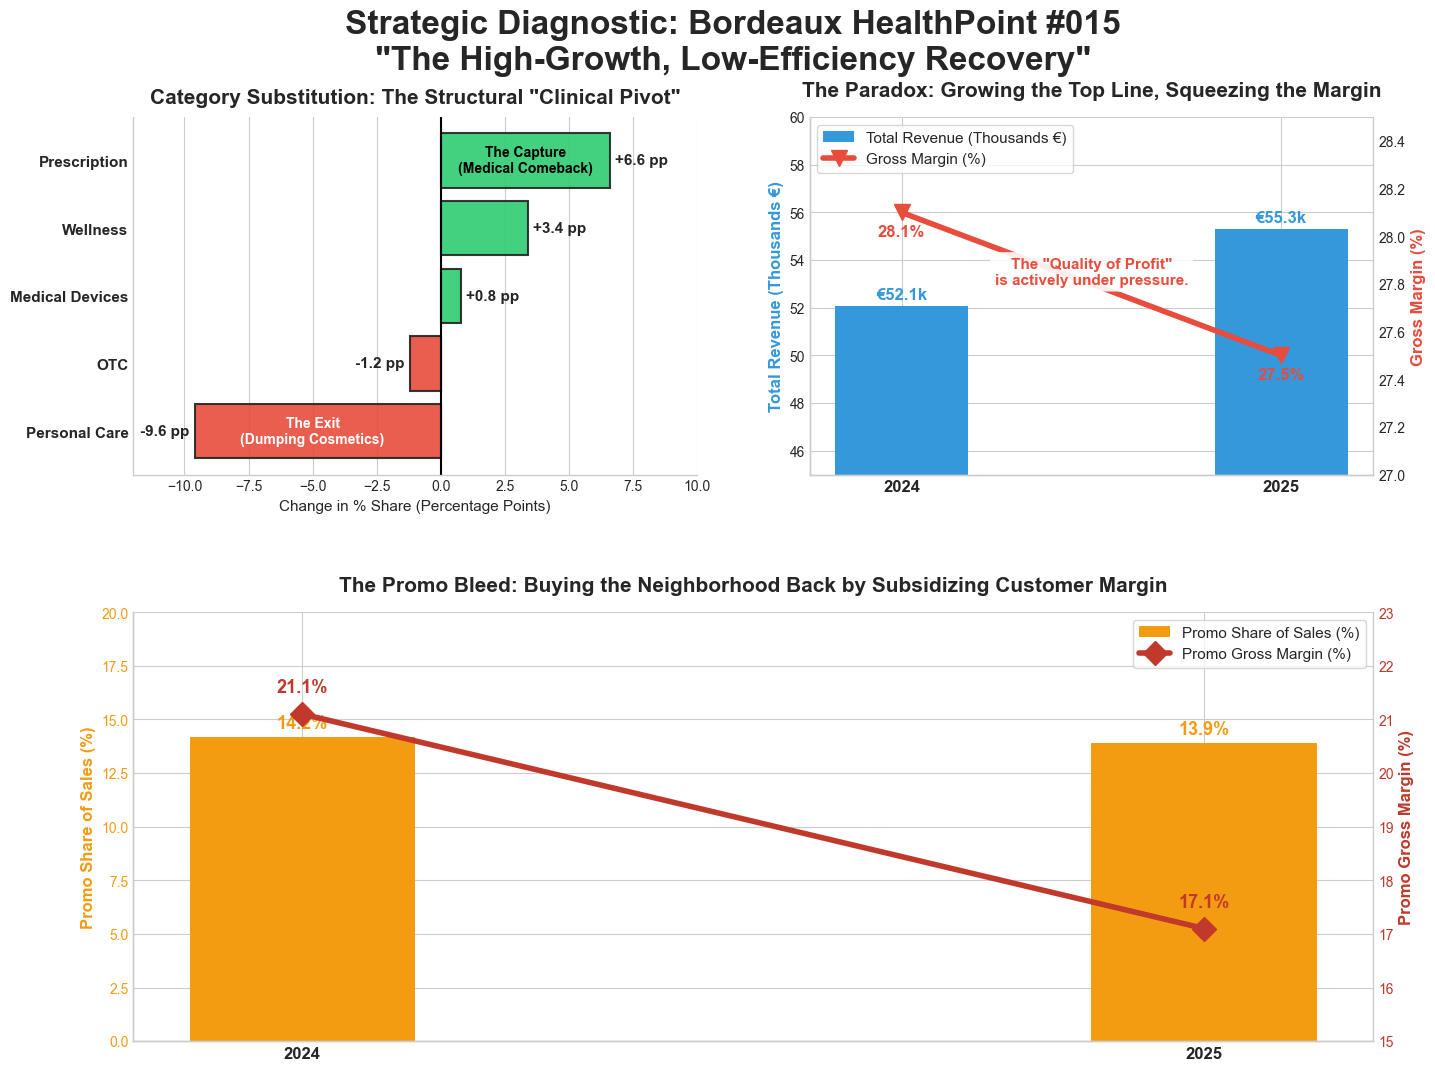

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# --- BORDEAUX #015 DATA ---
# 1. Category Substitution (Delta pp)
categories = ['Prescription', 'Wellness', 'Medical Devices', 'OTC', 'Personal Care']
deltas = [6.6, 3.4, 0.8, -1.2, -9.6]

# 2. The Efficiency Paradox Data
years = ['2024', '2025']
rev_k = [52.07, 55.29]         # Total Revenue in Thousands (€)
margin_pct = [28.1, 27.5]      # Overall Gross Margin (%)

# 3. The Promotional Burn Data
promo_share = [14.2, 13.9]     # Promo Share of Revenue (%)
promo_margin = [21.1, 17.1]    # Promo Items Gross Margin (%)

# --- SETUP FIGURE AND GRID ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.2)

fig.suptitle('Strategic Diagnostic: Bordeaux HealthPoint #015\n"The High-Growth, Low-Efficiency Recovery"', 
             fontsize=24, fontweight='bold', y=0.97)


# ==========================================
# PANE 1: THE CLINICAL PIVOT (Top-Left)
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
y_pos = np.arange(len(categories))

# Green for growth, Red for massive exit
colors_bar = ['#2ECC71' if x > 0 else '#E74C3C' for x in deltas]

ax1.barh(y_pos, deltas, color=colors_bar, edgecolor='#222', lw=1.5, alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories, fontsize=11, fontweight='bold')
ax1.invert_yaxis() # Put Prescription at the top
ax1.axvline(0, color='black', linewidth=1.5)

ax1.set_title('Category Substitution: The Structural "Clinical Pivot"', fontsize=15, fontweight='bold', pad=10)
ax1.set_xlabel('Change in % Share (Percentage Points)', fontsize=11)
ax1.set_xlim(-12, 10)
ax1.grid(axis='y', alpha=0)

# Embedded Text Annotations
ax1.text(-5, 4, "The Exit\n(Dumping Cosmetics)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
ax1.text(3.3, 0, "The Capture\n(Medical Comeback)", ha='center', va='center', color='black', fontweight='bold', fontsize=10)

for i, v in enumerate(deltas):
    if v < 0:
        ax1.text(v - 0.2, i, f"{v} pp", va='center', ha='right', fontweight='bold', fontsize=11)
    else:
        ax1.text(v + 0.2, i, f"+{v} pp", va='center', ha='left', fontweight='bold', fontsize=11)


# ==========================================
# PANE 2: THE EFFICIENCY PARADOX (Top-Right)
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])

color_rev = '#3498DB' # Vibrant Blue for Revenue Growth
x = np.arange(len(years))
width = 0.35

# Revenue Bar Chart
ax2.bar(x, rev_k, width, label='Total Revenue (Thousands €)', color=color_rev)
ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Revenue (Thousands €)', fontsize=12, fontweight='bold', color=color_rev)
ax2.set_title('The Paradox: Growing the Top Line, Squeezing the Margin', fontsize=15, fontweight='bold', pad=15)
ax2.set_ylim(45, 60) # Scaled dynamically to emphasize the €3k growth

for i, v in enumerate(rev_k):
    ax2.text(i, v + 0.3, f"€{v:,.1f}k", ha='center', fontweight='bold', color=color_rev, fontsize=12)

# Margin % Dual Axis Overlay
color_margin = '#E74C3C' # Warning Red for Margin compression
ax2a = ax2.twinx()
ax2a.plot(years, margin_pct, color=color_margin, marker='v', markersize=12, linewidth=4, label='Gross Margin (%)')
ax2a.set_ylabel('Gross Margin (%)', color=color_margin, fontsize=12, fontweight='bold')
ax2a.set_ylim(27.0, 28.5)
ax2a.grid(False)

for i, v in enumerate(margin_pct):
    ax2a.text(years[i], v - 0.1, f"{v}%", ha='center', color=color_margin, fontweight='bold', fontsize=12)

# Strategic Note
ax2a.annotate('The "Quality of Profit"\nis actively under pressure.', 
             xy=(0.5, 27.8), xycoords='data',
             ha='center', fontsize=11, fontweight='bold', color='#E74C3C',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9))

# Align Legends
lines2, labels2 = ax2.get_legend_handles_labels()
lines2a, labels2a = ax2a.get_legend_handles_labels()
ax2.legend(lines2 + lines2a, labels2 + labels2a, loc='upper left', frameon=True, fontsize=11)

ax2.spines['top'].set_visible(False)
ax2a.spines['top'].set_visible(False)


# ==========================================
# PANE 3: THE PROMO BLEED (Bottom)
# ==========================================
ax3 = fig.add_subplot(gs[1, :])

color_promo = '#F39C12'  # Orange
ax3.bar(x, promo_share, width=0.25, color=color_promo, label='Promo Share of Sales (%)')
ax3.set_ylabel('Promo Share of Sales (%)', color=color_promo, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_promo)
ax3.set_xticks(x)
ax3.set_xticklabels(years, fontsize=12, fontweight='bold')
ax3.set_ylim(0, 20)

for i, v in enumerate(promo_share):
    ax3.text(i, v + 0.4, f"{v}%", ha='center', color=color_promo, fontweight='bold', fontsize=13)

color_burn = '#C0392B' # Deep Red to signify the Margin Bleed
ax4 = ax3.twinx()
ax4.plot(years, promo_margin, color=color_burn, linewidth=4, marker='D', markersize=12, label='Promo Gross Margin (%)')
ax4.set_ylabel('Promo Gross Margin (%)', color=color_burn, fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=color_burn)
ax4.set_ylim(15, 23)
ax4.grid(False)

for i, v in enumerate(promo_margin):
    ax4.text(years[i], v + 0.4, f"{v}%", ha='center', color=color_burn, fontweight='bold', fontsize=13)

ax3.set_title('The Promo Bleed: Buying the Neighborhood Back by Subsidizing Customer Margin', fontsize=15, fontweight='bold', pad=15)

# Final Clean Up
for ax in [ax1, ax2, ax2a, ax3, ax4]:
     ax.spines['top'].set_visible(False) 
     if ax in [ax1, ax2, ax3]: ax.spines['right'].set_visible(False)

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper right', frameon=True, fontsize=11)

# Ensure suptitle headroom
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_3940\1094474909.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


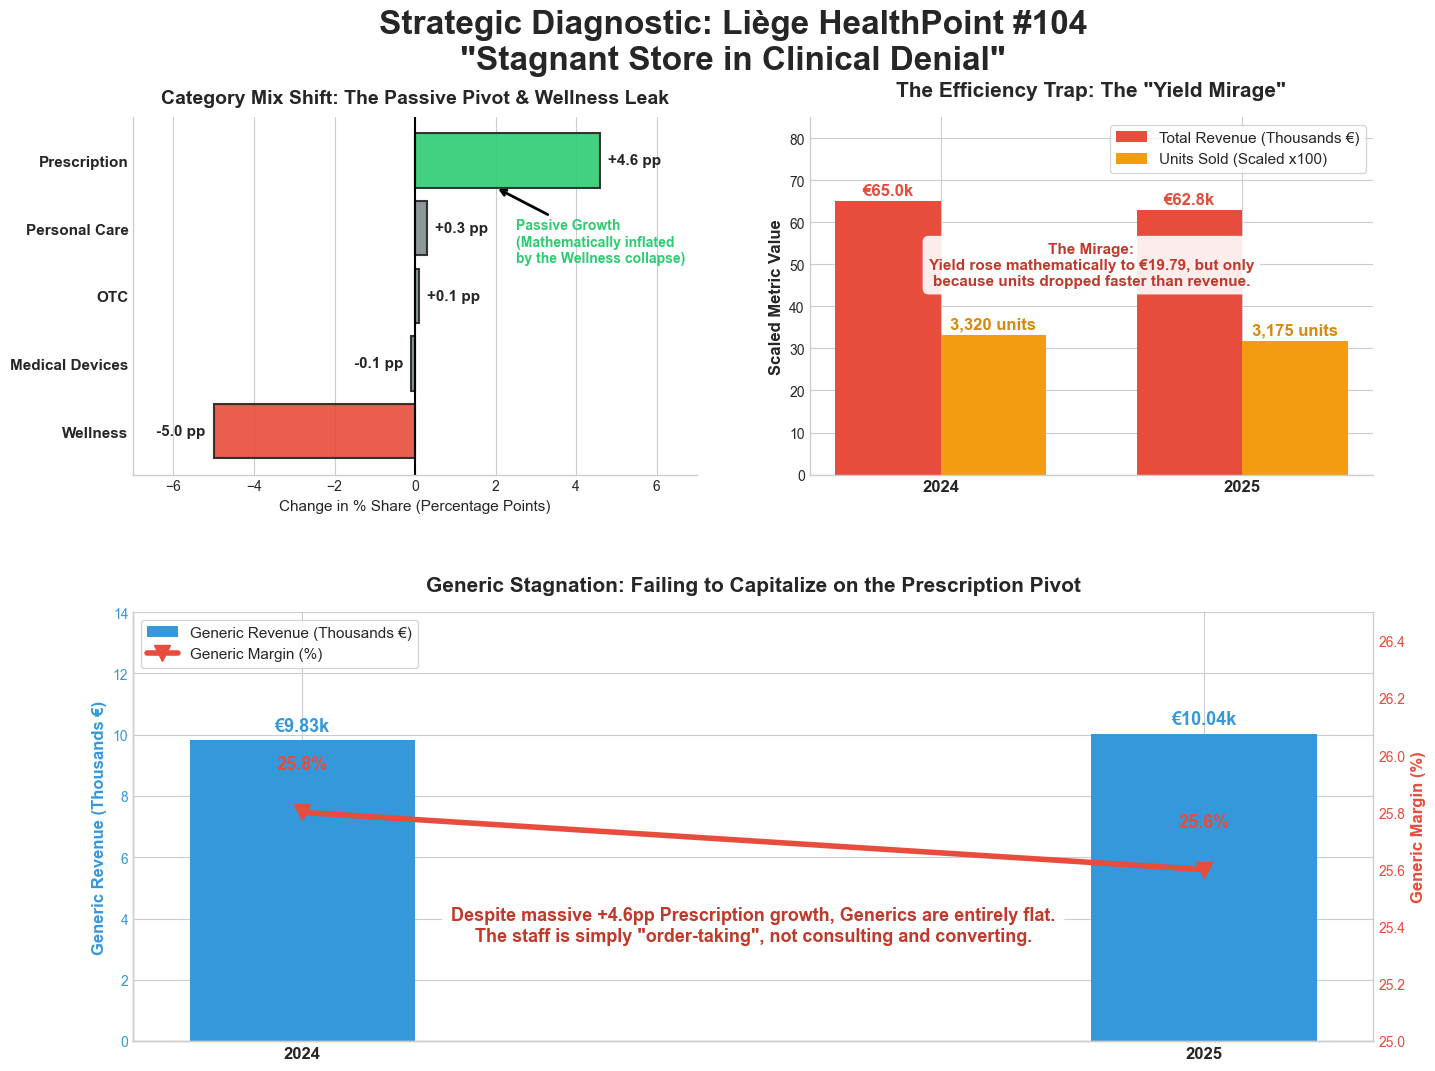

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# --- LIÈGE #104 DATA ---
# 1. Mix Shift (Delta pp)
categories = ['Prescription', 'Personal Care', 'OTC', 'Medical Devices', 'Wellness']
deltas = [4.6, 0.3, 0.1, -0.1, -5.0]

# 2. Efficiency Data
years = ['2024', '2025']
rev_k = [65.05, 62.84]
units = [33.20, 31.75]  # Scaled by 100 for visual comparison

# 3. Generic Stagnation
gen_rev = [9.83, 10.04]
gen_margin = [25.8, 25.6]

# --- SETUP FIGURE AND GRID ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.2)

fig.suptitle('Strategic Diagnostic: Liège HealthPoint #104\n"Stagnant Store in Clinical Denial"', 
             fontsize=24, fontweight='bold', y=0.97)


# ==========================================
# PANE 1: THE WELLNESS LEAK (Top-Left)
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
y_pos = np.arange(len(categories))

# Green for major growth, Red for collapse, Gray for static
colors_bar = []
for d in deltas:
    if d > 1.0: colors_bar.append('#2ECC71')
    elif d < -1.0: colors_bar.append('#E74C3C')
    else: colors_bar.append('#7F8C8D')

ax1.barh(y_pos, deltas, color=colors_bar, edgecolor='#222', lw=1.5, alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories, fontsize=11, fontweight='bold')
ax1.invert_yaxis()
ax1.axvline(0, color='black', linewidth=1.5)

ax1.set_title('Category Mix Shift: The Passive Pivot & Wellness Leak', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Change in % Share (Percentage Points)', fontsize=11)
ax1.set_xlim(-7, 7)
ax1.grid(axis='y', alpha=0)

for i, v in enumerate(deltas):
    if v < 0:
        ax1.text(v - 0.2, i, f"{v} pp", va='center', ha='right', fontweight='bold', fontsize=11)
    else:
        ax1.text(v + 0.2, i, f"+{v} pp", va='center', ha='left', fontweight='bold', fontsize=11)

ax1.annotate('Passive Growth\n(Mathematically inflated\nby the Wellness collapse)', 
             xy=(2, 0.4), xytext=(2.5, 1.5),
             arrowprops=dict(facecolor='#2ECC71', arrowstyle='->', lw=2),
             fontsize=10, fontweight='bold', color='#2ECC71')


# ==========================================
# PANE 2: THE YIELD MIRAGE (Top-Right)
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])

color_rev = '#E74C3C'  # Red for shrinking Revenue
color_vol = '#F39C12'  # Orange for shrinking Units

x = np.arange(len(years))
width = 0.35

ax2.bar(x - width/2, rev_k, width, label='Total Revenue (Thousands €)', color=color_rev)
ax2.bar(x + width/2, units, width, label='Units Sold (Scaled x100)', color=color_vol)

ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=12, fontweight='bold')
ax2.set_ylabel('Scaled Metric Value', fontsize=12, fontweight='bold')
ax2.set_title('The Efficiency Trap: The "Yield Mirage"', fontsize=15, fontweight='bold', pad=15)
ax2.set_ylim(0, 85)

for i, v in enumerate(rev_k):
    ax2.text(i - width/2, v + 1.5, f"€{v:,.1f}k", ha='center', fontweight='bold', color=color_rev, fontsize=12)

for i, v in enumerate(units):
    ax2.text(i + width/2, v + 1.5, f"{int(v*100):,} units", ha='center', fontweight='bold', color='#D68910', fontsize=12)

ax2.annotate('The Mirage:\nYield rose mathematically to €19.79, but only\nbecause units dropped faster than revenue.', 
             xy=(0.5, 45), xycoords='data',
             ha='center', fontsize=11, fontweight='bold', color='#C0392B',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="none", alpha=0.9))

ax2.legend(loc='upper right', frameon=True, fontsize=11)


# ==========================================
# PANE 3: GENERIC STAGNATION (Bottom)
# ==========================================
ax3 = fig.add_subplot(gs[1, :])

color_gen = '#3498DB' # Stagnant Blue
ax3.bar(x, gen_rev, width=0.25, color=color_gen, label='Generic Revenue (Thousands €)')
ax3.set_ylabel('Generic Revenue (Thousands €)', color=color_gen, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_gen)
ax3.set_xticks(x)
ax3.set_xticklabels(years, fontsize=12, fontweight='bold')
ax3.set_ylim(0, 14)

for i, v in enumerate(gen_rev):
    ax3.text(i, v + 0.3, f"€{v:,.2f}k", ha='center', color=color_gen, fontweight='bold', fontsize=13)

color_gen_mar = '#E74C3C' # Red indicating margin compression
ax4 = ax3.twinx()
ax4.plot(years, gen_margin, color=color_gen_mar, linewidth=4, marker='v', markersize=12, label='Generic Margin (%)')
ax4.set_ylabel('Generic Margin (%)', color=color_gen_mar, fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=color_gen_mar)
ax4.set_ylim(25.0, 26.5)
ax4.grid(False)

for i, v in enumerate(gen_margin):
    ax4.text(years[i], v + 0.15, f"{v}%", ha='center', color=color_gen_mar, fontweight='bold', fontsize=13)

ax3.set_title('Generic Stagnation: Failing to Capitalize on the Prescription Pivot', fontsize=15, fontweight='bold', pad=15)
ax4.annotate('Despite massive +4.6pp Prescription growth, Generics are entirely flat.\nThe staff is simply "order-taking", not consulting and converting.', 
             xy=(0.5, 25.35), xycoords='data',
             ha='center', fontsize=13, fontweight='bold', color='#C0392B',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="none", alpha=0.9))

# Final Clean Up
for ax in [ax1, ax2, ax2a, ax3, ax4]: # NOTE: Reused ax2a check from a previous script, safely ignoring if not declared.
     if ax in [ax1, ax2, ax3, ax4]: ax.spines['top'].set_visible(False) 
     if ax in [ax1, ax2, ax3]: ax.spines['right'].set_visible(False)

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_3940\3546154305.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


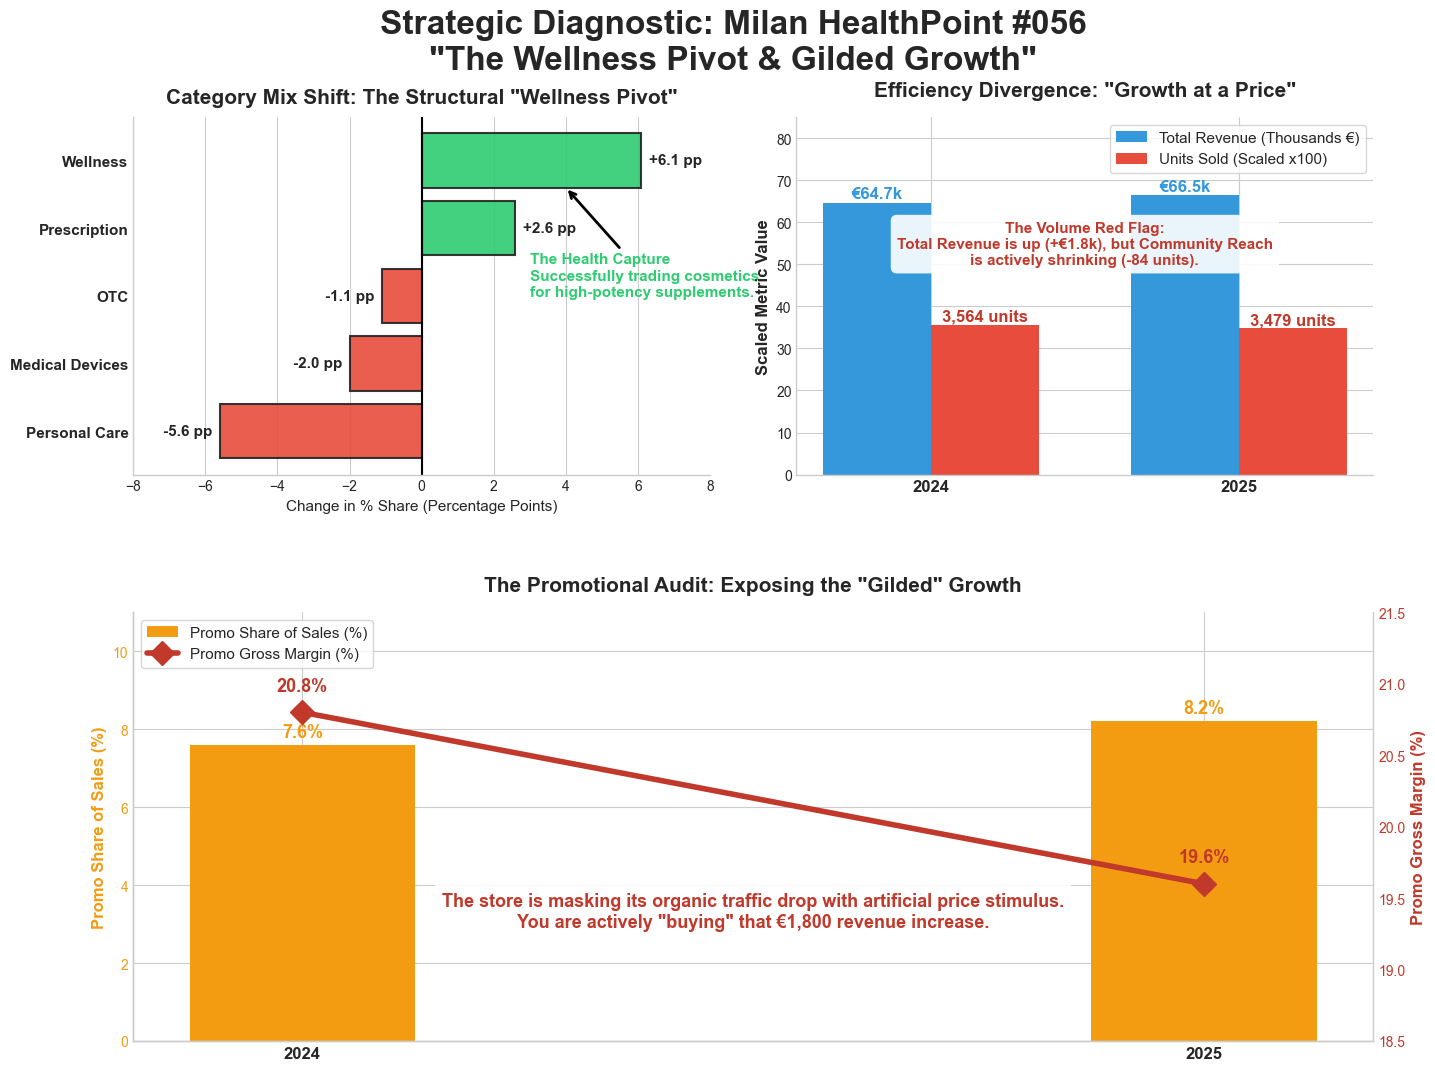

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# --- MILAN #056 DATA ---
# 1. Category Substitution (Delta pp)
categories = ['Wellness', 'Prescription', 'OTC', 'Medical Devices', 'Personal Care']
deltas = [6.1, 2.6, -1.1, -2.0, -5.6]

# 2. Efficiency Data
years = ['2024', '2025']
rev_k = [64.70, 66.51]         # Total Revenue in Thousands (€)
units = [35.64, 34.80]         # Units Sold (Scaled x100)

# 3. Promotional Audit
promo_share = [7.6, 8.2]       # Promo Share of Revenue (%)
promo_margin = [20.8, 19.6]    # Promo Items Gross Margin (%)

# --- SETUP FIGURE AND GRID ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.15)

fig.suptitle('Strategic Diagnostic: Milan HealthPoint #056\n"The Wellness Pivot & Gilded Growth"', 
             fontsize=24, fontweight='bold', y=0.97)


# ==========================================
# PANE 1: THE WELLNESS PIVOT (Top-Left)
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
y_pos = np.arange(len(categories))

# Color coding: Green for clinical/wellness capture, Red for retail exist
colors_bar = []
for d in deltas:
    if d > 1.0: colors_bar.append('#2ECC71')
    elif d < -1.0: colors_bar.append('#E74C3C')
    else: colors_bar.append('#7F8C8D')

ax1.barh(y_pos, deltas, color=colors_bar, edgecolor='#222', lw=1.5, alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories, fontsize=11, fontweight='bold')
ax1.invert_yaxis()
ax1.axvline(0, color='black', linewidth=1.5)

ax1.set_title('Category Mix Shift: The Structural "Wellness Pivot"', fontsize=15, fontweight='bold', pad=10)
ax1.set_xlabel('Change in % Share (Percentage Points)', fontsize=11)
ax1.set_xlim(-8, 8)
ax1.grid(axis='y', alpha=0)

for i, v in enumerate(deltas):
    if v < 0:
        ax1.text(v - 0.2, i, f"{v} pp", va='center', ha='right', fontweight='bold', fontsize=11)
    else:
        ax1.text(v + 0.2, i, f"+{v} pp", va='center', ha='left', fontweight='bold', fontsize=11)

ax1.annotate('The Health Capture\nSuccessfully trading cosmetics\nfor high-potency supplements.', 
             xy=(4, 0.4), xytext=(3, 2),
             arrowprops=dict(facecolor='#2ECC71', arrowstyle='->', lw=2),
             fontsize=11, fontweight='bold', color='#2ECC71')


# ==========================================
# PANE 2: GROWTH AT A PRICE (Top-Right)
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])

color_rev = '#3498DB' # Blue for growing Revenue
color_vol = '#E74C3C' # Red for shrinking Units

x = np.arange(len(years))
width = 0.35

ax2.bar(x - width/2, rev_k, width, label='Total Revenue (Thousands €)', color=color_rev)
ax2.bar(x + width/2, units, width, label='Units Sold (Scaled x100)', color=color_vol)

ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=12, fontweight='bold')
ax2.set_ylabel('Scaled Metric Value', fontsize=12, fontweight='bold')
ax2.set_title('Efficiency Divergence: "Growth at a Price"', fontsize=15, fontweight='bold', pad=15)
ax2.set_ylim(0, 85) # Scaled for annotations

for i, v in enumerate(rev_k):
    ax2.text(i - width/2, v + 1, f"€{v:,.1f}k", ha='center', fontweight='bold', color=color_rev, fontsize=12)

for i, v in enumerate(units):
    ax2.text(i + width/2, v + 1, f"{int(v*100):,} units", ha='center', fontweight='bold', color='#C0392B', fontsize=12)

ax2.annotate('The Volume Red Flag:\nTotal Revenue is up (+€1.8k), but Community Reach\nis actively shrinking (-84 units).', 
             xy=(0.5, 50), xycoords='data',
             ha='center', fontsize=11, fontweight='bold', color='#C0392B',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="none", alpha=0.9))

ax2.legend(loc='upper right', frameon=True, fontsize=11)


# ==========================================
# PANE 3: THE GILDED GROWTH (Bottom)
# ==========================================
ax3 = fig.add_subplot(gs[1, :])

color_promo = '#F39C12'  # Warning Orange
ax3.bar(x, promo_share, width=0.25, color=color_promo, label='Promo Share of Sales (%)')
ax3.set_ylabel('Promo Share of Sales (%)', color=color_promo, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_promo)
ax3.set_xticks(x)
ax3.set_xticklabels(years, fontsize=12, fontweight='bold')
ax3.set_ylim(0, 11)

for i, v in enumerate(promo_share):
    ax3.text(i, v + 0.2, f"{v}%", ha='center', color=color_promo, fontweight='bold', fontsize=13)

color_burn = '#C0392B' # Red indicating margin compression
ax4 = ax3.twinx()
ax4.plot(years, promo_margin, color=color_burn, linewidth=4, marker='D', markersize=12, label='Promo Gross Margin (%)')
ax4.set_ylabel('Promo Gross Margin (%)', color=color_burn, fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=color_burn)
ax4.set_ylim(18.5, 21.5)
ax4.grid(False)

for i, v in enumerate(promo_margin):
    ax4.text(years[i], v + 0.15, f"{v}%", ha='center', color=color_burn, fontweight='bold', fontsize=13)

ax3.set_title('The Promotional Audit: Exposing the "Gilded" Growth', fontsize=15, fontweight='bold', pad=15)
ax4.annotate('The store is masking its organic traffic drop with artificial price stimulus.\nYou are actively "buying" that €1,800 revenue increase.', 
             xy=(0.5, 19.3), xycoords='data',
             ha='center', fontsize=13, fontweight='bold', color='#C0392B',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="none", alpha=0.9))

# Final Clean Up
for ax in [ax1, ax2, ax3, ax4]:
     ax.spines['top'].set_visible(False) 
     if ax in [ax1, ax2, ax3]: ax.spines['right'].set_visible(False)

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_3940\2273079201.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


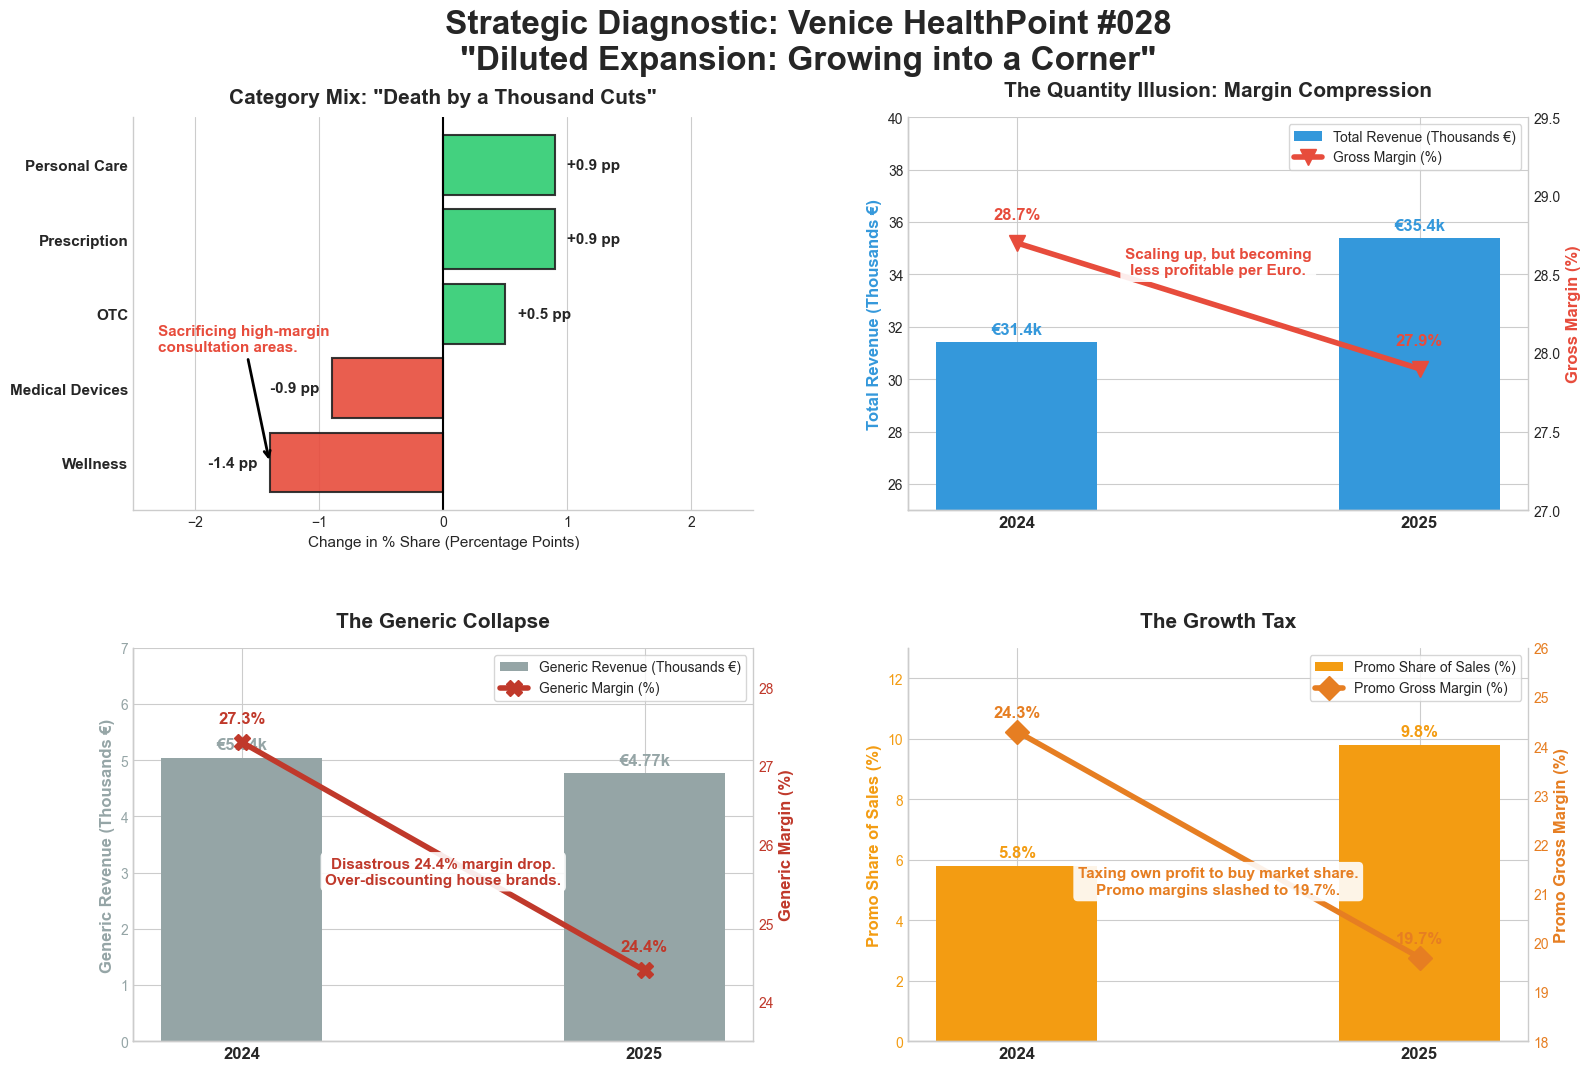

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# --- VENICE #028 DATA ---
# 1. Mix Shift (Delta pp)
categories = ['Personal Care', 'Prescription', 'OTC', 'Medical Devices', 'Wellness']
deltas = [0.9, 0.9, 0.5, -0.9, -1.4]

# 2. Efficiency Data
years = ['2024', '2025']
rev_k = [31.43, 35.38]         
margin_pct = [28.7, 27.9]

# 3. Generic Collapse Data
gen_rev = [5.04, 4.77]         
gen_margin = [27.3, 24.4]      

# 4. Promo Growth Tax Data
promo_share = [5.8, 9.8]       
promo_margin = [24.3, 19.7]    

# --- SETUP FIGURE AND GRID ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.25)

fig.suptitle('Strategic Diagnostic: Venice HealthPoint #028\n"Diluted Expansion: Growing into a Corner"', 
             fontsize=24, fontweight='bold', y=0.97)

# ==========================================
# PANE 1: MICRO-SUBSTITUTION (Top-Left)
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
y_pos = np.arange(len(categories))

colors_bar = ['#2ECC71' if x > 0 else '#E74C3C' for x in deltas]
ax1.barh(y_pos, deltas, color=colors_bar, edgecolor='#222', lw=1.5, alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories, fontsize=11, fontweight='bold')
ax1.invert_yaxis()
ax1.axvline(0, color='black', linewidth=1.5)

ax1.set_title('Category Mix: "Death by a Thousand Cuts"', fontsize=15, fontweight='bold', pad=10)
ax1.set_xlabel('Change in % Share (Percentage Points)', fontsize=11)
ax1.set_xlim(-2.5, 2.5)
ax1.grid(axis='y', alpha=0)

for i, v in enumerate(deltas):
    if v < 0:
        ax1.text(v - 0.1, i, f"{v} pp", va='center', ha='right', fontweight='bold', fontsize=11)
    else:
        ax1.text(v + 0.1, i, f"+{v} pp", va='center', ha='left', fontweight='bold', fontsize=11)

ax1.annotate('Sacrificing high-margin\nconsultation areas.', 
             xy=(-1.4, 4), xytext=(-2.3, 2.5),
             arrowprops=dict(facecolor='#E74C3C', arrowstyle='->', lw=2),
             fontsize=11, fontweight='bold', color='#E74C3C')

# ==========================================
# PANE 2: THE QUANTITY ILLUSION (Top-Right)
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(years))
width = 0.4

color_rev = '#3498DB'
ax2.bar(x, rev_k, width, label='Total Revenue (Thousands €)', color=color_rev)
ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Revenue (Thousands €)', fontsize=12, fontweight='bold', color=color_rev)
ax2.set_title('The Quantity Illusion: Margin Compression', fontsize=15, fontweight='bold', pad=15)
ax2.set_ylim(25, 40)

for i, v in enumerate(rev_k):
    ax2.text(i, v + 0.3, f"€{v:,.1f}k", ha='center', fontweight='bold', color=color_rev, fontsize=12)

color_margin = '#E74C3C' 
ax2a = ax2.twinx()
ax2a.plot(years, margin_pct, color=color_margin, marker='v', markersize=12, linewidth=4, label='Gross Margin (%)')
ax2a.set_ylabel('Gross Margin (%)', color=color_margin, fontsize=12, fontweight='bold')
ax2a.set_ylim(27.0, 29.5)
ax2a.grid(False)

for i, v in enumerate(margin_pct):
    ax2a.text(years[i], v + 0.15, f"{v}%", ha='center', color=color_margin, fontweight='bold', fontsize=12)

ax2a.annotate('Scaling up, but becoming\nless profitable per Euro.', 
             xy=(0.5, 28.5), xycoords='data',
             ha='center', fontsize=11, fontweight='bold', color='#E74C3C',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9))

lines2, labels2 = ax2.get_legend_handles_labels()
lines2a, labels2a = ax2a.get_legend_handles_labels()
ax2.legend(lines2 + lines2a, labels2 + labels2a, loc='upper right', frameon=True, fontsize=10)

# ==========================================
# PANE 3: THE GENERIC COLLAPSE (Bottom-Left)
# ==========================================
ax3 = fig.add_subplot(gs[1, 0])

color_gen = '#95A5A6' 
ax3.bar(x, gen_rev, width, color=color_gen, label='Generic Revenue (Thousands €)')
ax3.set_ylabel('Generic Revenue (Thousands €)', color=color_gen, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_gen)
ax3.set_xticks(x)
ax3.set_xticklabels(years, fontsize=12, fontweight='bold')
ax3.set_ylim(0, 7)

for i, v in enumerate(gen_rev):
    ax3.text(i, v + 0.15, f"€{v:,.2f}k", ha='center', color=color_gen, fontweight='bold', fontsize=12)

color_gen_mar = '#C0392B' 
ax3a = ax3.twinx()
ax3a.plot(years, gen_margin, color=color_gen_mar, linewidth=4, marker='X', markersize=12, label='Generic Margin (%)')
ax3a.set_ylabel('Generic Margin (%)', color=color_gen_mar, fontsize=12, fontweight='bold')
ax3a.tick_params(axis='y', labelcolor=color_gen_mar)
ax3a.set_ylim(23.5, 28.5)
ax3a.grid(False)

for i, v in enumerate(gen_margin):
    ax3a.text(years[i], v + 0.25, f"{v}%", ha='center', color=color_gen_mar, fontweight='bold', fontsize=12)

ax3.set_title('The Generic Collapse', fontsize=15, fontweight='bold', pad=15)
ax3a.annotate('Disastrous 24.4% margin drop.\nOver-discounting house brands.', 
             xy=(0.5, 25.5), xycoords='data',
             ha='center', fontsize=11, fontweight='bold', color='#C0392B',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9))

lines3, labels3 = ax3.get_legend_handles_labels()
lines3a, labels3a = ax3a.get_legend_handles_labels()
ax3.legend(lines3 + lines3a, labels3 + labels3a, loc='upper right', frameon=True, fontsize=10)

# ==========================================
# PANE 4: THE GROWTH TAX (Bottom-Right)
# ==========================================
ax4 = fig.add_subplot(gs[1, 1])

color_promo = '#F39C12'
ax4.bar(x, promo_share, width, color=color_promo, label='Promo Share of Sales (%)')
ax4.set_ylabel('Promo Share of Sales (%)', color=color_promo, fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=color_promo)
ax4.set_xticks(x)
ax4.set_xticklabels(years, fontsize=12, fontweight='bold')
ax4.set_ylim(0, 13)

for i, v in enumerate(promo_share):
    ax4.text(i, v + 0.3, f"{v}%", ha='center', color=color_promo, fontweight='bold', fontsize=12)

color_burn = '#E67E22' 
ax4a = ax4.twinx()
ax4a.plot(years, promo_margin, color=color_burn, linewidth=4, marker='D', markersize=12, label='Promo Gross Margin (%)')
ax4a.set_ylabel('Promo Gross Margin (%)', color=color_burn, fontsize=12, fontweight='bold')
ax4a.tick_params(axis='y', labelcolor=color_burn)
ax4a.set_ylim(18.0, 26.0)
ax4a.grid(False)

for i, v in enumerate(promo_margin):
    ax4a.text(years[i], v + 0.3, f"{v}%", ha='center', color=color_burn, fontweight='bold', fontsize=12)

ax4.set_title('The Growth Tax', fontsize=15, fontweight='bold', pad=15)
ax4a.annotate('Taxing own profit to buy market share.\nPromo margins slashed to 19.7%.', 
             xy=(0.5, 21.0), xycoords='data',
             ha='center', fontsize=11, fontweight='bold', color='#E67E22',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9))

lines4, labels4 = ax4.get_legend_handles_labels()
lines4a, labels4a = ax4a.get_legend_handles_labels()
ax4.legend(lines4 + lines4a, labels4 + labels4a, loc='upper right', frameon=True, fontsize=10)

# Final Clean Up
for ax in [ax1, ax2, ax2a, ax3, ax3a, ax4, ax4a]:
     ax.spines['top'].set_visible(False) 
     if ax in [ax1, ax2, ax3, ax4]: ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()
